In [ ]:
import sys
sys.version

'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

# **Lorenz-63時系列予測**

In [ ]:
def lorenz_f(XYZ):
    X, Y, Z = XYZ
    return np.array([10.0*(Y - X), (X*(28.0 - Z) - Y), (X * Y - 8.0/3*Z)])

def lorenz_x_RK(t):
    XYZ = np.array([0.5, 0.1, 0.2])
    dt = 0.01
    Xset = [XYZ[0]]
    for _ in range(t + 1000):  # burn-in 1000
        k1 = lorenz_f(XYZ)
        k2 = lorenz_f(XYZ + dt/2 * k1)
        k3 = lorenz_f(XYZ + dt/2 * k2)
        k4 = lorenz_f(XYZ + dt * k3)
        XYZ += dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        Xset.append(XYZ[0])
    return np.array(Xset[1000:])  # X(t) 連続値


import matplotlib.pyplot as plt
import numpy as np

def plot_timeseries_compare(y_true, y_pred, *, start=0, length=300, title=None):
    """
    y_true, y_pred: 1D arrays (same length)
    start: プロット開始インデックス
    length: 表示点数
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    assert y_true.shape == y_pred.shape

    end = min(start + length, y_true.size)
    t = np.arange(start, end)

    plt.figure(figsize=(12, 4))
    plt.plot(t, y_true[start:end], label="True", lw=2)
    plt.plot(t, y_pred[start:end], label="Predicted", lw=1.5, alpha=0.8)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    if title is not None:
        plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
from typing import Tuple, Optional

def simulate_and_fit_one_pass_scalar(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U: np.ndarray,                   # shape (T,)  入力: u(t)
    Y: np.ndarray,                   # shape (T,)  教師: u(t+1)
    *,
    ridge: float = 1e-2,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",         # "pm" or "plus"
    input_mode: str = "scale",       # "scale" or "replace"
    Win: Optional[np.ndarray] = None,# shape (1, M) 入力マスク（固定）。Noneなら生成
    Win_scale: float = 1.0,
    x0: Optional[np.ndarray] = None, # shape (M,) 初期状態（無励起確率）
    carry_state: bool = True,        # True: 時刻に沿って状態を引き継ぐ
) -> Tuple[np.ndarray, float, np.ndarray, np.ndarray, np.ndarray]:
    """
    出力:
      w: (M,)        Wout
      b: float       bias
      y_hat: (T,)    予測
      S: (T,M)       状態列（out_prob）
      xT: (M,)       最終状態（無励起確率）
    """
    # -------------------------
    # 形チェック（ここだけ 10→1 の最小変更）
    # -------------------------
    U = np.asarray(U, dtype=float).reshape(-1)          # (T,)
    Y = np.asarray(Y, dtype=float).reshape(-1)          # (T,)
    if U.ndim != 1:
        raise ValueError(f"U must be 1D (T,). got {U.shape}")
    T = U.shape[0]
    if Y.size != T:
        raise ValueError(f"Y must be length T={T}. got {Y.size}")

    # 内部は (T,1) として扱う（以降のロジックはほぼそのまま）
    U1 = U.reshape(T, 1)  # (T,1)

    M = 12 * N
    rng = np.random.default_rng(seed)

    # 入力マスク Win: (1,M)（ここだけ 10→1）
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, dtype=float)
        if Win.shape != (1, M):
            raise ValueError(f"Win must be shape (1,{M}). got {Win.shape}")

    # 初期状態 x（無励起確率 0..1）
    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.asarray(x0, dtype=float).reshape(-1).copy()
        if x_state.size != M:
            raise ValueError(f"x0 must be length {M}. got {x_state.size}")
        x_state = np.clip(x_state, 0.0, 1.0)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    # -------------------------
    # 時系列を流して状態列 S を作る
    # -------------------------
    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # (A) スカラー入力(1次元) → M次元入力 u_vec
        # u_vec[j] = sum_i U1[t,i] * Win[i,j] だが i=0 だけ
        u_vec = U1[t] @ Win  # (M,)

        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # (B) ① 確率注入（無励起確率 x_state を使う）
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # (C) ②〜⑤ 干渉ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        # (D) ⑦ 合成
        fin = (wnet + u_vec) / sqrt2

        # (E) ⑧ 非線形：検出確率 out_prob を状態とする（サンプリングしない）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)

        # log(p0_like) = log(coef) - |fin|^2 + tanh(r) * fin^2
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        # 数値安定化：exp の実部をクリップ
        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        log_p0_safe = re + 1j * im

        p0_like = np.exp(log_p0_safe)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        # (F) 状態更新（無励起確率として次へ）
        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    xT = x_state.copy()

    # -------------------------
    # Wout を ridge で学習： y_hat = S @ w + b
    # -------------------------
    X = np.hstack([S, np.ones((T, 1))])               # (T, M+1)
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))  # biasは正則化しない
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)   # (M+1,)
    w = theta[:M]
    b = float(theta[M])

    y_hat = S @ w + b

    return w, b, y_hat, S, xT


def make_scalar_dataset(x_series: np.ndarray, start_t: int, T: int):
    """
    入力:  U[k] = x(t),    t = start_t + k
    教師:  Y[k] = x(t+1)
    """
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 0:
        raise ValueError("start_t must be >= 0")
    if start_t + T + 1 > len(x):
        raise ValueError("range out of x_series (need t+1)")

    U = x[start_t : start_t + T]                 # (T,)
    Y = x[start_t + 1 : start_t + T + 1]         # (T,)
    return U, Y

MSE= 9.602898810493022 Corr= 0.9177001823384291


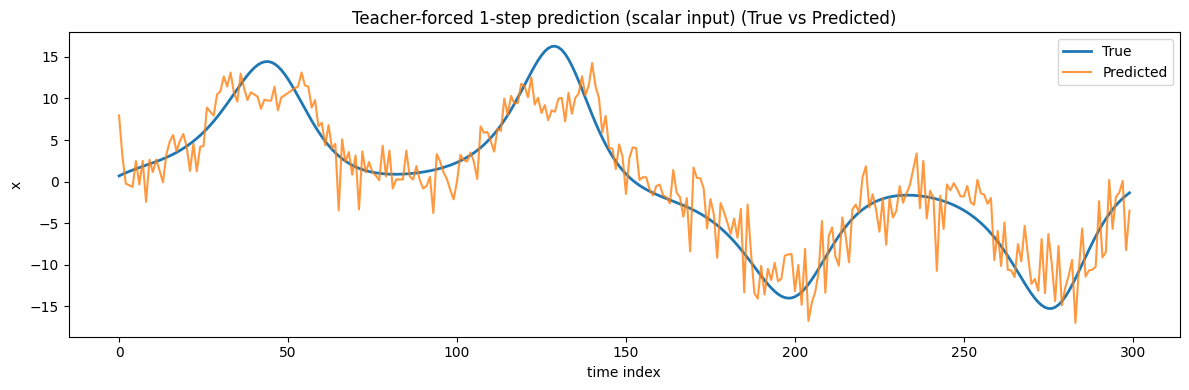

In [ ]:
# Lorenz
x_series = lorenz_x_RK(6000)

# データ（例：t=1000から1000ステップ分）
U, Y = make_scalar_dataset(x_series, start_t=1000, T=1000)

# 学習＋予測
w, b, y_hat, S, xT = simulate_and_fit_one_pass_scalar(
    N=1,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U=U, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (scalar input) (True vs Predicted)"
)

MSE= 1.747259569284683 Corr= 0.9855370559582849


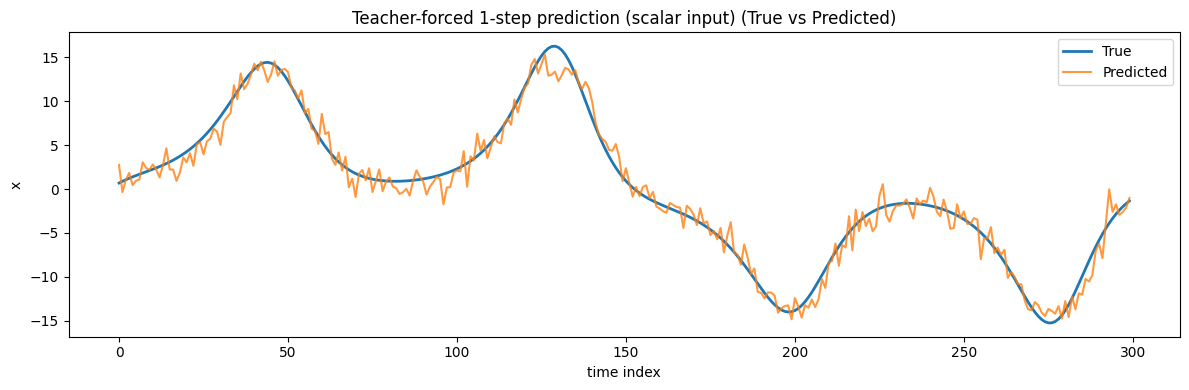

In [ ]:
# Lorenz
x_series = lorenz_x_RK(6000)

# データ（例：t=1000から1000ステップ分）
U, Y = make_scalar_dataset(x_series, start_t=1000, T=1000)

# 学習＋予測
w, b, y_hat, S, xT = simulate_and_fit_one_pass_scalar(
    N=10,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U=U, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (scalar input) (True vs Predicted)"
)

MSE= 0.0007556887405911405 Corr= 0.9999937937717855


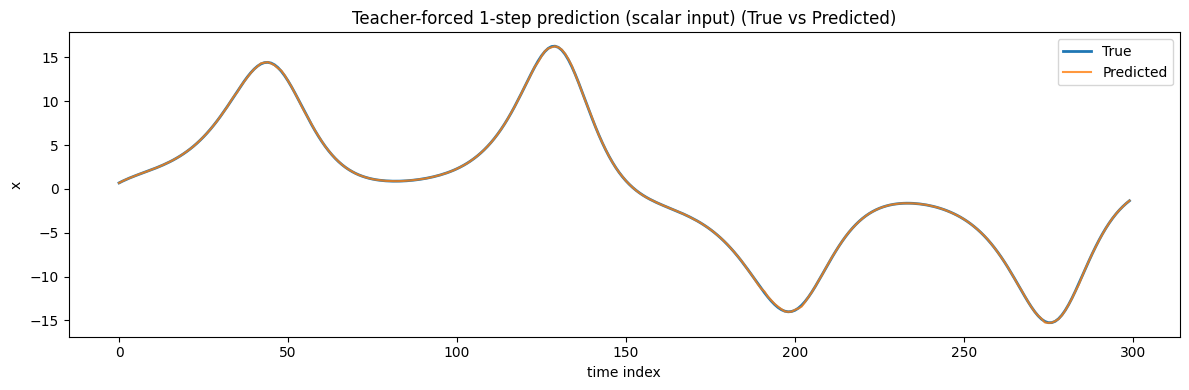

In [ ]:
# Lorenz
x_series = lorenz_x_RK(6000)

# データ（例：t=1000から1000ステップ分）
U, Y = make_scalar_dataset(x_series, start_t=1000, T=1000)

# 学習＋予測
w, b, y_hat, S, xT = simulate_and_fit_one_pass_scalar(
    N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U=U, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (scalar input) (True vs Predicted)"
)

**リザバーサイズを大きくしていった時のQRCと古典ESNのローレンツ時系列予測における精度比較**

(1-1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# -------------------------
# データセット: 入力 U=x(t), 教師 Y=x(t+1)
# -------------------------
def make_scalar_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 0:
        raise ValueError("start_t must be >= 0")
    if start_t + T + 1 > len(x):
        raise ValueError("range out of x_series (need t+1)")
    U = x[start_t : start_t + T]                 # (T,)
    Y = x[start_t + 1 : start_t + T + 1]         # (T,)
    return U, Y

# -------------------------
# 共通: ridge readout（bias付き、biasは正則化しない）
# -------------------------
def fit_readout_ridge(S: np.ndarray, Y: np.ndarray, ridge: float = 1e-2) -> Tuple[np.ndarray, float]:
    S = np.asarray(S, float)
    Y = np.asarray(Y, float).reshape(-1)
    T, M = S.shape
    if Y.size != T:
        raise ValueError("S and Y length mismatch")
    X = np.hstack([S, np.ones((T, 1))])  # (T, M+1)
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))  # biasは正則化しない
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)
    w = theta[:M]
    b = float(theta[M])
    return w, b

def predict_readout(S: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    return np.asarray(S, float) @ np.asarray(w, float) + float(b)

def mse_corr(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    y_true = np.asarray(y_true, float).reshape(-1)
    y_pred = np.asarray(y_pred, float).reshape(-1)
    mse = float(np.mean((y_true - y_pred) ** 2))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    return mse, corr

def plot_true_vs_pred(y_true, y_pred, title=""):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label="True", lw=2)
    plt.plot(y_pred, label="Predicted", lw=1.5, alpha=0.85)
    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# (A) QRC: out_prob 状態列（入力はスカラー）
# =========================================================
def simulate_qrc_states_outprob_scalar(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U: np.ndarray,             # (T,)  スカラー入力
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",   # "pm" or "plus"
    input_mode: str = "scale", # "scale" or "replace"
    Win: Optional[np.ndarray] = None,     # (1,M)
    Win_scale: float = 1.0,
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      S: (T,M) out_prob（検出確率）状態列
      xT: (M,) 最終状態（無励起確率）
    """
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]
    U1 = U.reshape(T, 1)  # (T,1)

    M = 12 * N
    rng = np.random.default_rng(seed)

    # 入力マスク (1,M)  ※10→1の最小変更
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, float)
        if Win.shape != (1, M):
            raise ValueError(f"Win must be (1,{M})")

    # 状態（無励起確率）
    x_state = np.zeros(M, dtype=float)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # スカラー → M次元入力
        u_vec = (U1[t] @ Win)  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / np.sqrt(2.0)

        # ⑧ 非線形（安全版）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    return S, x_state


# =========================================================
# (B) 決定論的 ESN (tanh) ：同じ M=12N、入力はスカラー
# =========================================================
def simulate_esn_states_tanh_scalar(
    M: int,
    U: np.ndarray,  # (T,) スカラー入力
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    標準的 ESN:
      x_{t+1} = (1-leak)*x_t + leak*tanh( Wres x_t + Win u_t + b )
    Returns:
      S: (T,M) 状態列
      params: Wres, Win, b
    """
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]

    rng = np.random.default_rng(seed)

    # Win: (1,M)  ※10→1
    Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(input_scale)

    # Wres: (M,M) を作ってスペクトル半径調整
    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)

    eigvals = np.linalg.eigvals(Wres)
    sr = np.max(np.abs(eigvals)) + 1e-12
    Wres = Wres * (float(spectral_radius) / sr)

    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # u(t) はスカラーなので (1,) にしてから @ Win
        pre = x @ Wres + np.array([U[t]]) @ Win + b
        x_new = np.tanh(pre)
        x = (1.0 - leak_rate) * x + leak_rate * x_new
        S[t] = x

    params = {"Wres": Wres, "Win": Win, "b": b}
    return S, params


# =========================================================
# 実験: QRC vs ESN を同じ M で比較してプロット（スカラー入力）
# =========================================================
def compare_qrc_vs_esn_scalar(
    x_series: np.ndarray,
    *,
    N: int = 100,
    start_t: int = 1000,
    T: int = 1000,
    seed: int = 43,
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,
    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    U, Y = make_scalar_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    # --- QRC
    S_qrc, _ = simulate_qrc_states_outprob_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
    )
    wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
    Yhat_qrc = predict_readout(S_qrc, wq, bq)
    mse_qrc, corr_qrc = mse_corr(Y, Yhat_qrc)

    # --- ESN
    S_esn, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn, Y, ridge=ridge)
    Yhat_esn = predict_readout(S_esn, we, be)
    mse_esn, corr_esn = mse_corr(Y, Yhat_esn)

    print(f"[QRC] M={M}  MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN] M={M}  MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")

    plot_true_vs_pred(Y, Yhat_qrc, title=f"QRC (out_prob) Teacher-forced 1-step | scalar | N={N}, M={M}")
    plot_true_vs_pred(Y, Yhat_esn, title=f"ESN (tanh) Teacher-forced 1-step | scalar | M={M}")

    return {
        "Y": Y,
        "Yhat_qrc": Yhat_qrc,
        "Yhat_esn": Yhat_esn,
        "metrics": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        }
    }

[QRC] M=12  MSE=9.602899  Corr=0.917700
[ESN] M=12  MSE=0.437869  Corr=0.996395


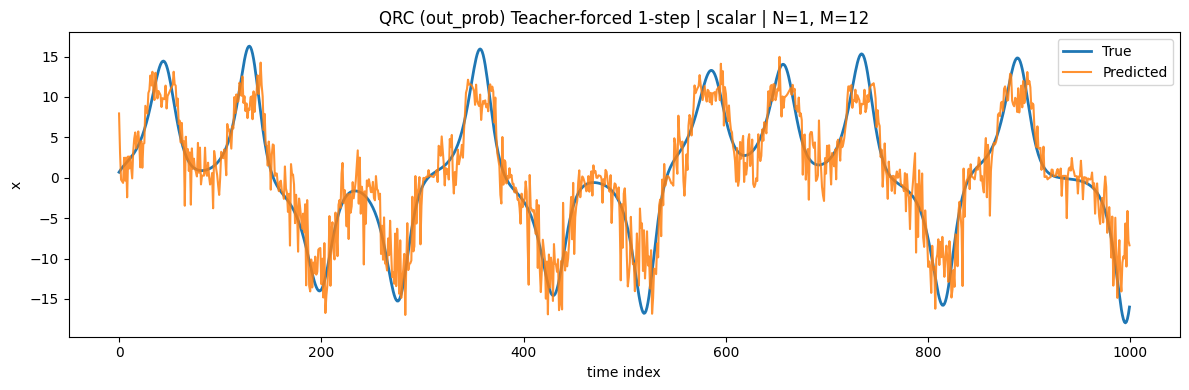

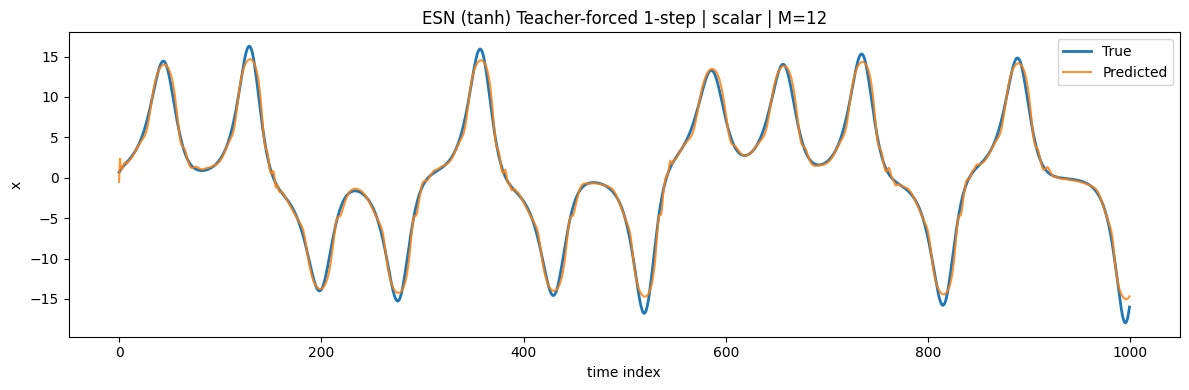

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=1,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=120  MSE=1.747260  Corr=0.985537
[ESN] M=120  MSE=0.000882  Corr=0.999993


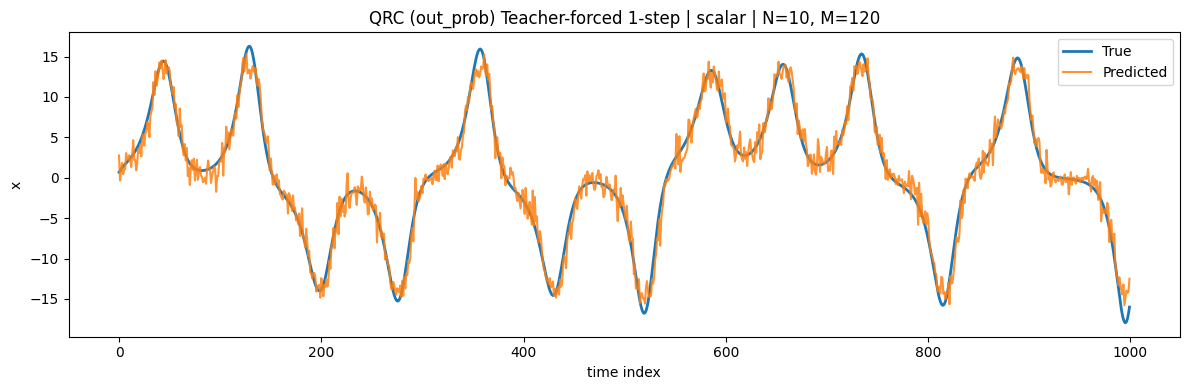

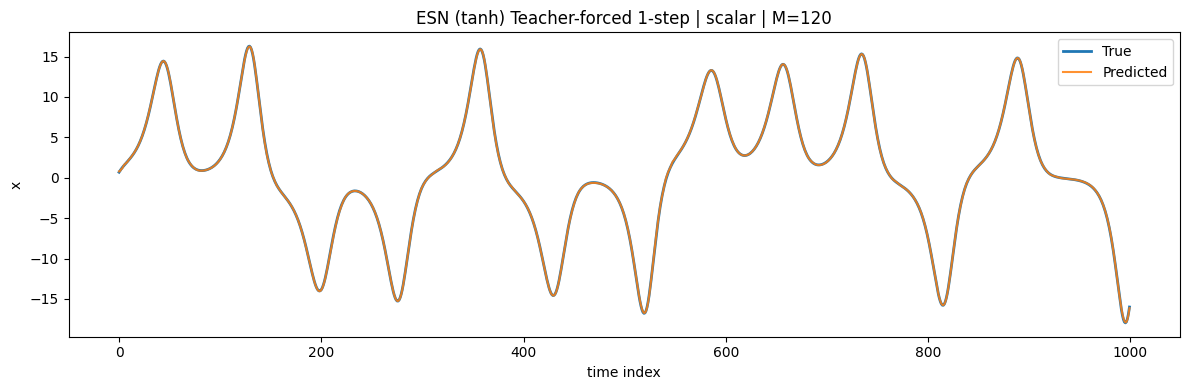

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=10,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=1200  MSE=0.000756  Corr=0.999994
[ESN] M=1200  MSE=0.000192  Corr=0.999998


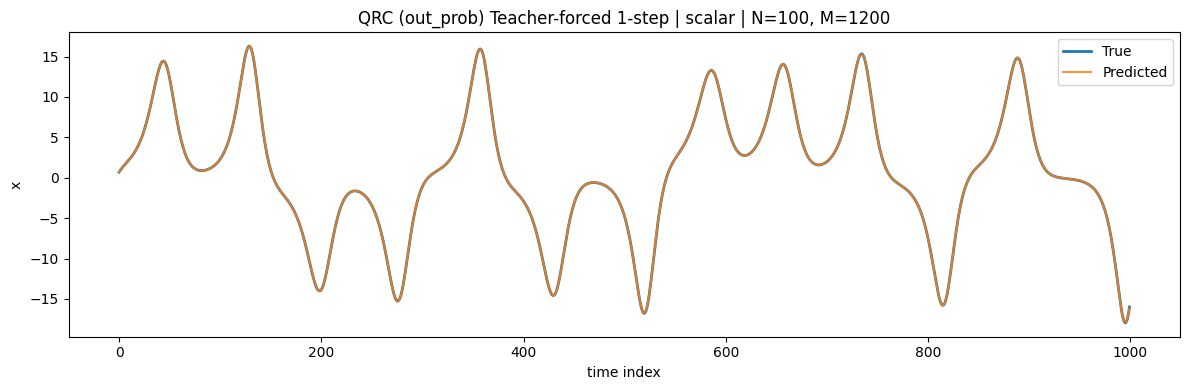

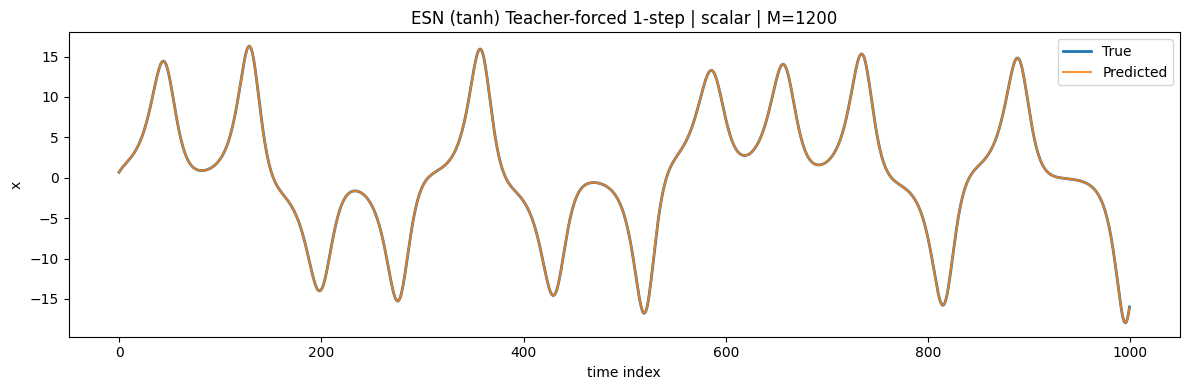

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=100,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=12000  MSE=0.000000  Corr=1.000000
[ESN] M=12000  MSE=0.000020  Corr=1.000000


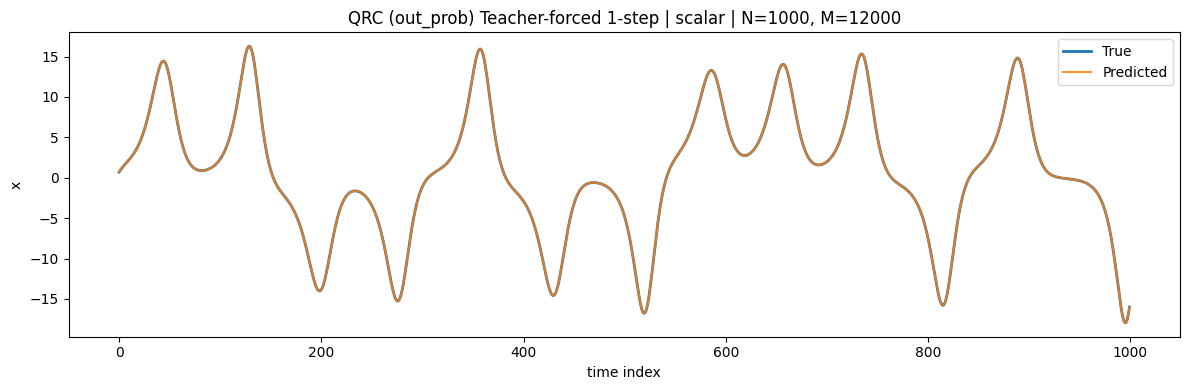

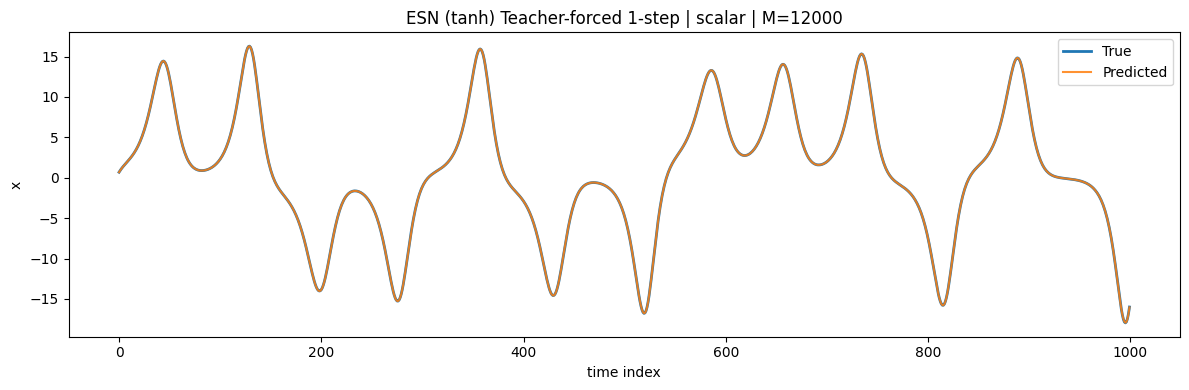

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=1000,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

In [ ]:
import numpy as np
from typing import Tuple, Optional

# -------------------------
# データセット: 入力 U=x(t), 教師 Y=x(t+1)
# -------------------------
def make_scalar_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 0:
        raise ValueError("start_t must be >= 0")
    if start_t + T + 1 > len(x):
        raise ValueError("range out of x_series (need t+1)")
    U = x[start_t : start_t + T]                 # (T,)
    Y = x[start_t + 1 : start_t + T + 1]         # (T,)
    return U, Y


def simulate_qrc_states_sampled01_scalar(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U: np.ndarray,            # (T,) スカラー入力
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",   # "pm" or "plus"
    input_mode: str = "scale", # "scale" or "replace"
    Win: Optional[np.ndarray] = None,  # (1,M)
    Win_scale: float = 1.0,
    carry_state: bool = True,
    # --- sampling / noise ---
    shots: int = 10,
    flip_p: float = 0.10,
    return_out_prob: bool = False,
) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray], np.ndarray]:
    """
    QRC状態を「検出確率→0/1サンプル→フリップ→shots平均」で生成（スカラー入力版）。

    Returns:
      S_mean : (T,M)   各時刻・各モードの「検出率推定」（shots平均; 0..1）
      xT     : (M,)    最終状態（無励起確率として更新する場合）
      P      : (T,M)   out_prob（return_out_prob=Trueなら）
      Win    : (1,M)   入力マスク（再利用用）
    """
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]
    U1 = U.reshape(T, 1)  # (T,1)

    M = 12 * N
    rng = np.random.default_rng(seed)

    # 入力マスク (1,M)  ※10→1
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, float)
        if Win.shape != (1, M):
            raise ValueError(f"Win must be (1,{M})")

    # 状態（無励起確率）
    x_state = np.zeros(M, dtype=float)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S_mean = np.empty((T, M), dtype=float)
    P = np.empty((T, M), dtype=float) if return_out_prob else None

    shots = int(max(1, shots))
    flip_p = float(np.clip(flip_p, 0.0, 1.0))

    for t in range(T):
        # スカラー → M次元入力
        u_vec = U1[t] @ Win  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入（無励起確率 x_state）
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / sqrt2

        # ⑧ out_prob（安全版）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        if return_out_prob:
            P[t] = out_prob

        # ---- sampling / flip / shots平均 ----
        samples_sum = np.zeros(M, dtype=float)
        for _ in range(shots):
            sample = (rng.random(M) < out_prob).astype(np.int8)  # 0/1
            if flip_p > 0.0:
                flip = (rng.random(M) < flip_p).astype(np.int8)  # 0/1
                sample = sample ^ flip
            samples_sum += sample.astype(float)

        out_mean01 = samples_sum / shots
        S_mean[t] = out_mean01

        # 状態更新（無励起確率として）
        if carry_state:
            x_state = np.clip(1.0 - out_mean01, 0.0, 1.0)

    return S_mean, x_state, P, Win


def fit_readout_ridge(S: np.ndarray, Y: np.ndarray, ridge: float = 1e-2):
    S = np.asarray(S, float)
    Y = np.asarray(Y, float).reshape(-1)
    T, M = S.shape
    X = np.hstack([S, np.ones((T, 1))])
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)
    w = theta[:M]
    b = float(theta[M])
    return w, b

def mse_corr(y_true: np.ndarray, y_pred: np.ndarray):
    y_true = np.asarray(y_true, float).reshape(-1)
    y_pred = np.asarray(y_pred, float).reshape(-1)
    mse = float(np.mean((y_true - y_pred) ** 2))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    return mse, corr

def plot_true_vs_pred(y_true, y_pred, title=""):
    import matplotlib.pyplot as plt
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label="True", lw=2)
    plt.plot(y_pred, label="Predicted", lw=1.5, alpha=0.85)
    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()


def qrc_teacher_forced_eval_sampled01_scalar(
    x_series: np.ndarray,
    *,
    N: int,
    start_t: int,
    T: int,
    seed: int = 43,
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    ridge: float = 1e-2,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale: float = 1.0,
    carry_state: bool = True,
    shots: int = 10,
    flip_p: float = 0.10,
):
    # 入力U=x(t), 教師Y=x(t+1)
    U, Y = make_scalar_dataset_next(x_series, start_t=start_t, T=T)

    S, xT, _, Win = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r, U=U,
        seed=seed, norm_const=norm_const,
        sign_mode=sign_mode, input_mode=input_mode,
        Win=None, Win_scale=Win_scale,
        carry_state=carry_state,
        shots=shots, flip_p=flip_p,
        return_out_prob=False
    )

    w, b = fit_readout_ridge(S, Y, ridge=ridge)
    Yhat = S @ w + b
    mse, corr = mse_corr(Y, Yhat)

    return {
        "Y": Y, "Yhat": Yhat,
        "mse": mse, "corr": corr,
        "w": w, "b": b,
        "Win": Win, "xT": xT
    }

[QRC sampled01 clean]  MSE=16.652998  Corr=0.852234
[QRC sampled01 flip12.5] MSE=26.742023  Corr=0.748657


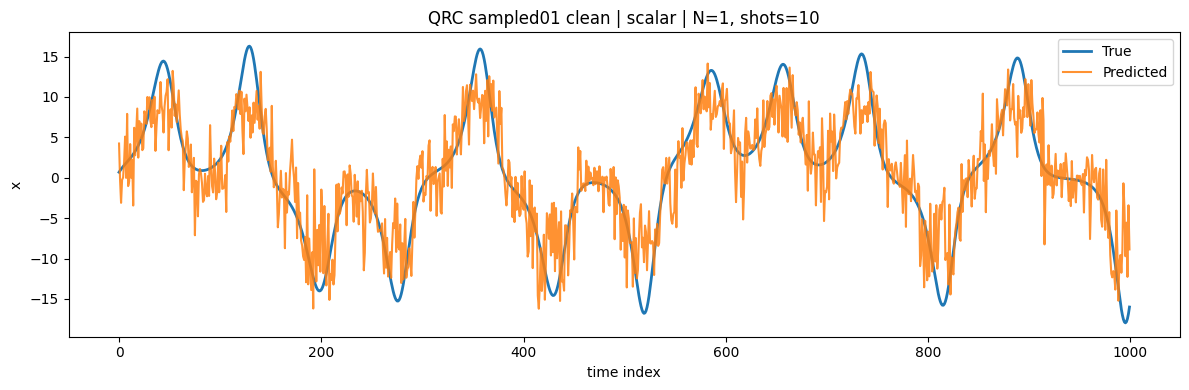

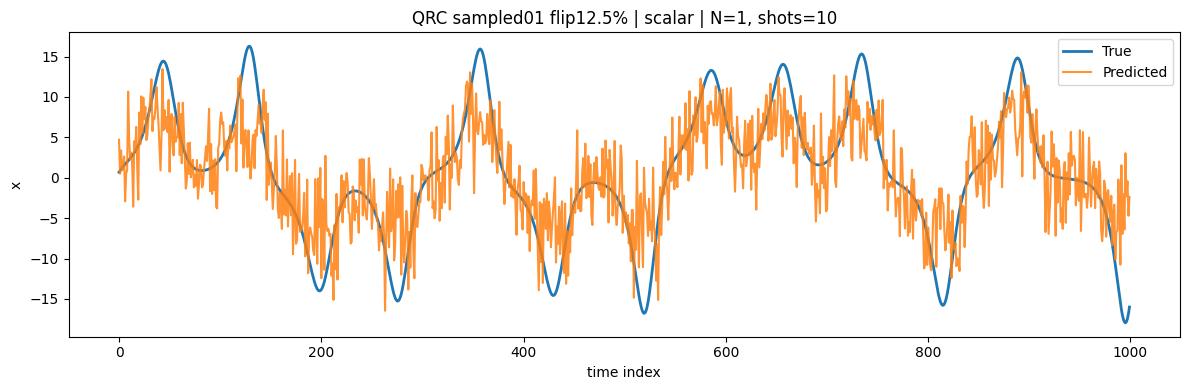

In [ ]:
N = 1
start_t = 1000
T = 1000
seed = 43

# (A) ノイズなし（shots平均だけ）
res_clean = qrc_teacher_forced_eval_sampled01_scalar(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.0
)

# (B) フリップ12.5%
res_flip = qrc_teacher_forced_eval_sampled01_scalar(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.125
)

print(f"[QRC sampled01 clean]  MSE={res_clean['mse']:.6f}  Corr={res_clean['corr']:.6f}")
print(f"[QRC sampled01 flip12.5] MSE={res_flip['mse']:.6f}  Corr={res_flip['corr']:.6f}")

plot_true_vs_pred(res_clean["Y"], res_clean["Yhat"], title=f"QRC sampled01 clean | scalar | N={N}, shots=10")
plot_true_vs_pred(res_flip["Y"],  res_flip["Yhat"],  title=f"QRC sampled01 flip12.5% | scalar | N={N}, shots=10")

[QRC sampled01 clean]  MSE=0.000129  Corr=0.999999
[QRC sampled01 flip12.5] MSE=0.000041  Corr=1.000000


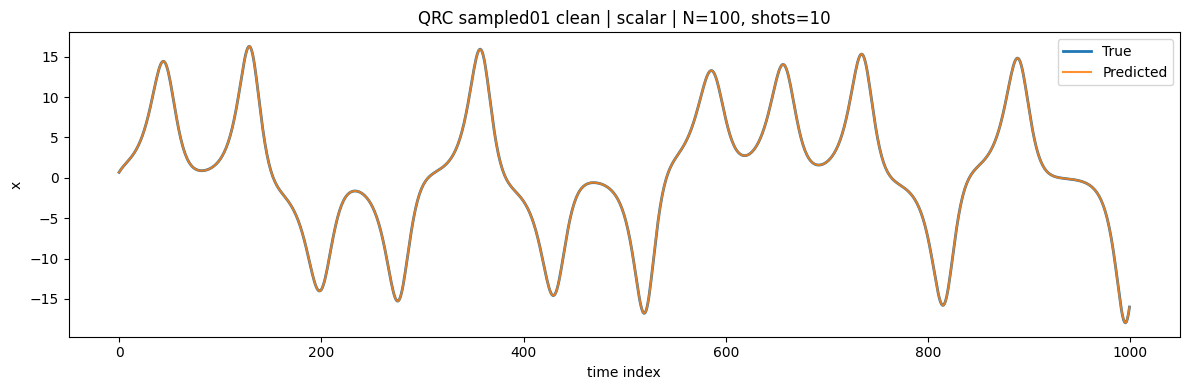

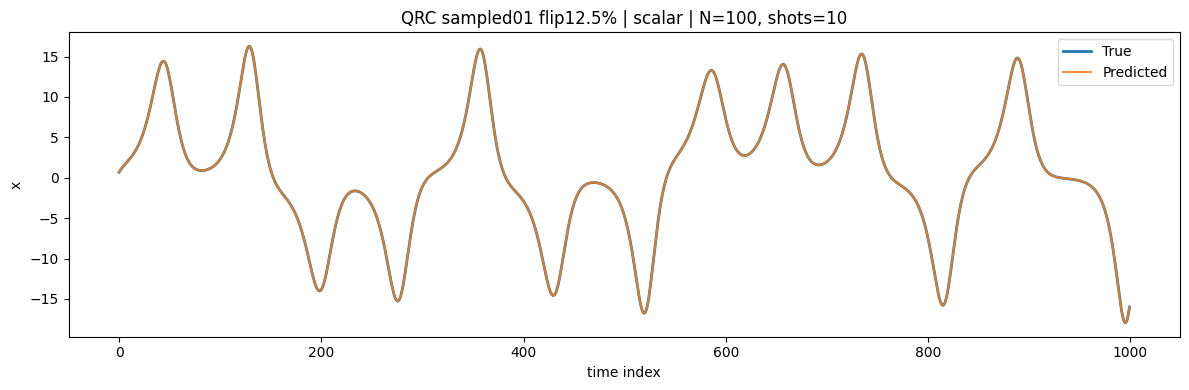

In [ ]:
N = 100
start_t = 1000
T = 1000
seed = 43

# (A) ノイズなし（shots平均だけ）
res_clean = qrc_teacher_forced_eval_sampled01_scalar(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.0
)

# (B) フリップ12.5%
res_flip = qrc_teacher_forced_eval_sampled01_scalar(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.125
)

print(f"[QRC sampled01 clean]  MSE={res_clean['mse']:.6f}  Corr={res_clean['corr']:.6f}")
print(f"[QRC sampled01 flip12.5] MSE={res_flip['mse']:.6f}  Corr={res_flip['corr']:.6f}")

plot_true_vs_pred(res_clean["Y"], res_clean["Yhat"], title=f"QRC sampled01 clean | scalar | N={N}, shots=10")
plot_true_vs_pred(res_flip["Y"],  res_flip["Yhat"],  title=f"QRC sampled01 flip12.5% | scalar | N={N}, shots=10")

**フリップエラーが起きた時の予測精度比較**

(1-3)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sweep_flip_noise_curve_scalar(
    x_series,
    *,
    N=100,
    start_t=1000,
    T=1000,
    seed=43,
    alpha=1.0,
    beta=0.7,
    squeeze_r=0.3,
    ridge=1e-2,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win_scale=1.0,
    carry_state=True,
    shots=10,
    flip_grid=None,
    n_seeds=1,            # seed をずらして平均したいなら >1
    seed_stride=1000,     # seedのずらし幅
    plot=True
):
    """
    スカラー入力版:
      qrc_teacher_forced_eval_sampled01_scalar を呼び出して、
      flip_p をスイープして MSE/Corr を集計・プロットする
    """
    if flip_grid is None:
        flip_grid = np.linspace(0.0, 0.30, 16)  # 0%〜30% を16点

    flip_grid = np.asarray(flip_grid, float)

    mses_mean, mses_std = [], []
    corrs_mean, corrs_std = [], []

    for fp in flip_grid:
        mses, corrs = [], []
        for k in range(n_seeds):
            s = int(seed + k * seed_stride)
            res = qrc_teacher_forced_eval_sampled01_scalar(
                x_series,
                N=N, start_t=start_t, T=T, seed=s,
                alpha=alpha, beta=beta, squeeze_r=squeeze_r,
                ridge=ridge, norm_const=norm_const,
                sign_mode=sign_mode, input_mode=input_mode,
                Win_scale=Win_scale, carry_state=carry_state,
                shots=shots, flip_p=float(fp)
            )
            mses.append(res["mse"])
            corrs.append(res["corr"])

        mses = np.asarray(mses, float)
        corrs = np.asarray(corrs, float)
        mses_mean.append(mses.mean()); mses_std.append(mses.std(ddof=0))
        corrs_mean.append(corrs.mean()); corrs_std.append(corrs.std(ddof=0))

    mses_mean = np.asarray(mses_mean)
    mses_std  = np.asarray(mses_std)
    corrs_mean = np.asarray(corrs_mean)
    corrs_std  = np.asarray(corrs_std)

    if plot:
        # MSE vs flip_p
        plt.figure(figsize=(7,4))
        plt.errorbar(flip_grid, mses_mean, yerr=mses_std, fmt='o-', capsize=3)
        plt.xlabel("flip_p (measurement error probability)")
        plt.ylabel("MSE (teacher-forced 1-step)")
        plt.title(f"QRC sampled01 (scalar): MSE vs flip_p  | N={N}, shots={shots}, T={T}, n_seeds={n_seeds}")
        plt.tight_layout()
        plt.show()

        # Corr vs flip_p
        plt.figure(figsize=(7,4))
        plt.errorbar(flip_grid, corrs_mean, yerr=corrs_std, fmt='o-', capsize=3)
        plt.xlabel("flip_p (measurement error probability)")
        plt.ylabel("Correlation (teacher-forced 1-step)")
        plt.title(f"QRC sampled01 (scalar): Corr vs flip_p | N={N}, shots={shots}, T={T}, n_seeds={n_seeds}")
        plt.tight_layout()
        plt.show()

    return {
        "flip_grid": flip_grid,
        "mse_mean": mses_mean,
        "mse_std": mses_std,
        "corr_mean": corrs_mean,
        "corr_std": corrs_std,
    }

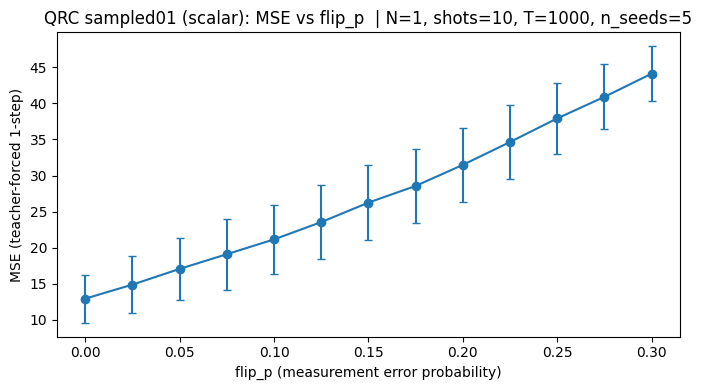

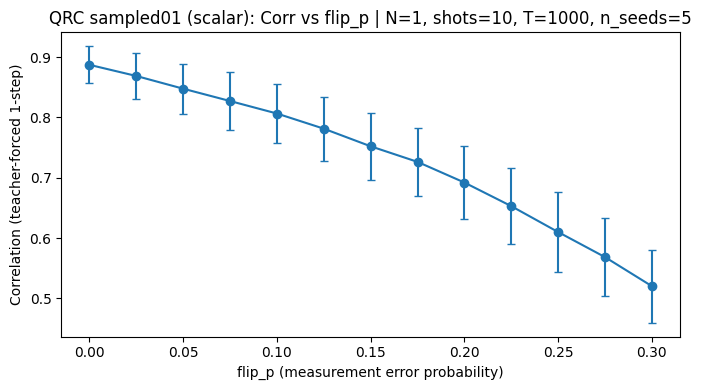

In [ ]:
out = sweep_flip_noise_curve_scalar(
     x_series,
     N=1, start_t=1000, T=1000,
     seed=43,
     shots=10,
     flip_grid=np.linspace(0, 0.30, 13),
     n_seeds=5,
 )

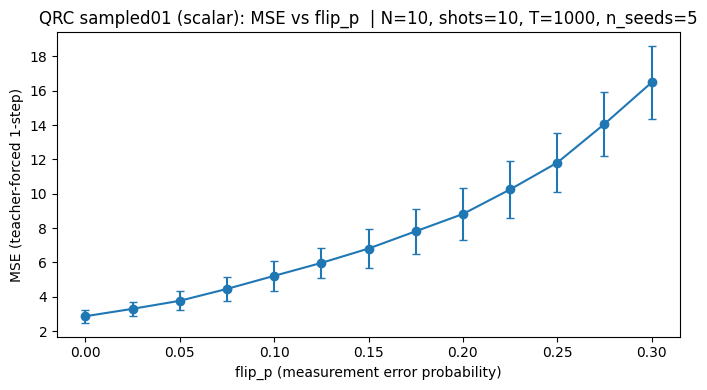

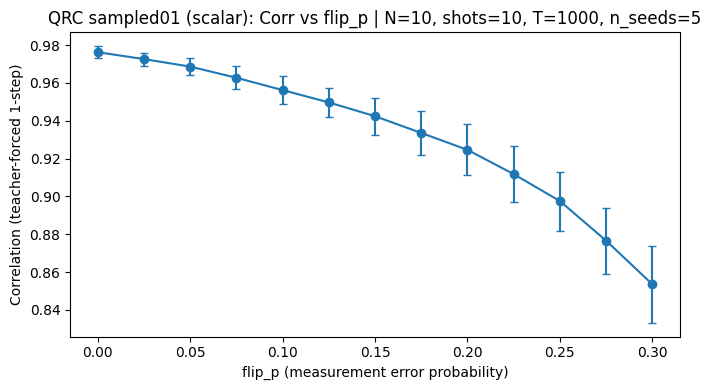

In [ ]:
out = sweep_flip_noise_curve_scalar(
     x_series,
     N=10, start_t=1000, T=1000,
     seed=43,
     shots=10,
     flip_grid=np.linspace(0, 0.30, 13),
     n_seeds=5,
 )

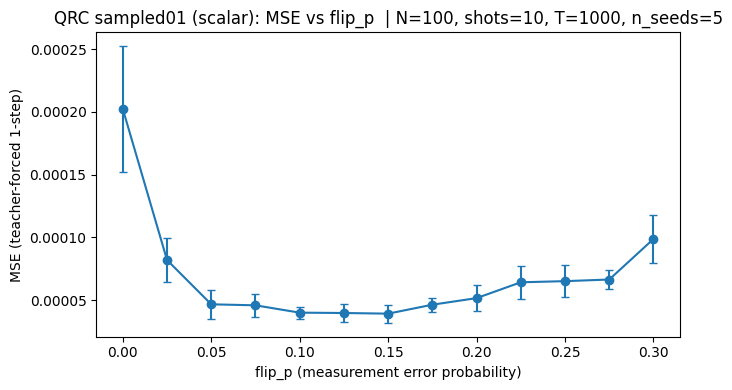

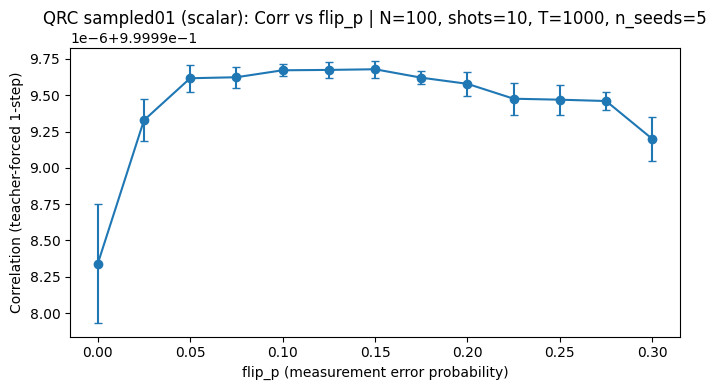

In [ ]:
 out = sweep_flip_noise_curve_scalar(
     x_series,
     N=100, start_t=1000, T=1000,
     seed=43,
     shots=10,
     flip_grid=np.linspace(0, 0.30, 13),
     n_seeds=5,
 )

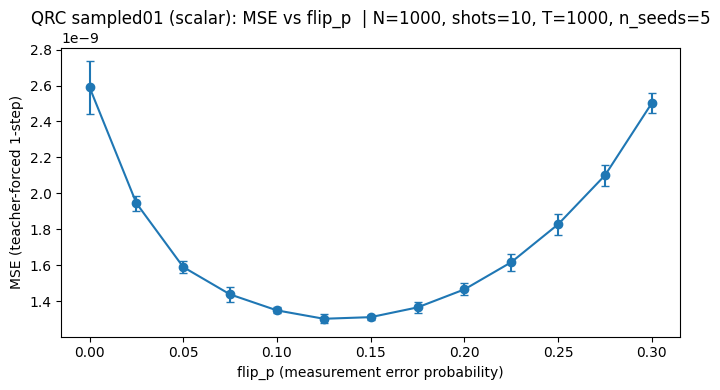

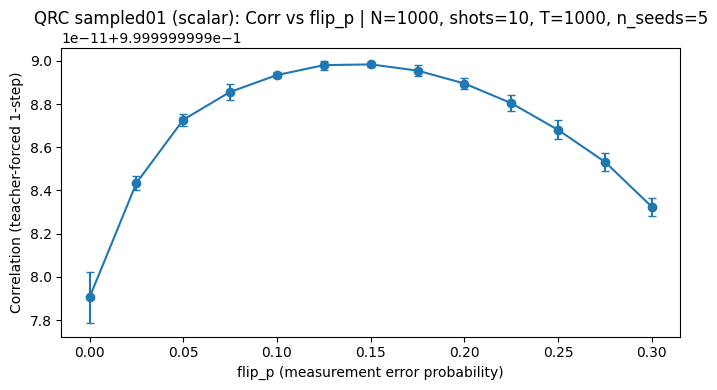

In [ ]:
out = sweep_flip_noise_curve_scalar(
     x_series,
     N=1000, start_t=1000, T=1000,
     seed=43,
     shots=10,
     flip_grid=np.linspace(0, 0.30, 13),
     n_seeds=5,
 )

**サンプリングの試行回数を変えた時の性能比較**

(1-2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence, Dict, Any, List

def sweep_shots_qrc_teacher_forced(
    x_series: np.ndarray,
    *,
    N: int,
    start_t: int,
    T: int,
    seed: int = 43,
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    ridge: float = 1e-2,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale: float = 1.0,
    carry_state: bool = True,
    flip_p: float = 0.0,
    shots_list: Sequence[int] = (1, 5, 10, 15, 20, 25),
    return_all_runs: bool = False,
) -> Dict[str, Any]:
    """
    qrc_teacher_forced_eval_sampled01_scalar() を shots でスイープして性能を集計。

    Returns:
      {
        "shots_list": [...],
        "mse": np.ndarray shape (K,),
        "corr": np.ndarray shape (K,),
        "runs": list (optional)  # return_all_runs=Trueのとき、各shotsのres辞書を格納
      }
    """
    shots_list = [int(s) for s in shots_list]
    mses: List[float] = []
    corrs: List[float] = []
    runs: List[Dict[str, Any]] = []

    for shots in shots_list:
        res = qrc_teacher_forced_eval_sampled01_scalar(
            x_series,
            N=N, start_t=start_t, T=T, seed=seed,
            alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            ridge=ridge,
            norm_const=norm_const,
            sign_mode=sign_mode,
            input_mode=input_mode,
            Win_scale=Win_scale,
            carry_state=carry_state,
            shots=shots,
            flip_p=flip_p,
        )
        mses.append(float(res["mse"]))
        corrs.append(float(res["corr"]))
        if return_all_runs:
            runs.append(res)

        print(f"shots={shots:>2d} | flip_p={flip_p:.3f} | MSE={res['mse']:.6g} | Corr={res['corr']:.6g}")

    out = {
        "shots_list": shots_list,
        "mse": np.array(mses, dtype=float),
        "corr": np.array(corrs, dtype=float),
    }
    if return_all_runs:
        out["runs"] = runs
    return out


def show_sweep_result_table_and_plot(result: Dict[str, Any], title: str = ""):
    shots = np.asarray(result["shots_list"], dtype=int)
    mse = np.asarray(result["mse"], dtype=float)
    corr = np.asarray(result["corr"], dtype=float)

    # ---- 表（print）----
    print("\n=== sweep result ===")
    if title:
        print(title)
    print("shots | mse        | corr")
    print("----- | ---------- | ----------")
    for s, m, c in zip(shots, mse, corr):
        print(f"{s:>5d} | {m:>10.6g} | {c:>10.6g}")

    # ---- 簡易プロット（2枚）----
    plt.figure(figsize=(6, 4))
    plt.plot(shots, mse, marker="o")
    plt.xlabel("shots")
    plt.ylabel("MSE")
    plt.title(title + (" (MSE)" if title else "MSE vs shots"))
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(shots, corr, marker="o")
    plt.xlabel("shots")
    plt.ylabel("Corr")
    plt.title(title + (" (Corr)" if title else "Corr vs shots"))
    plt.tight_layout()
    plt.show()

shots= 1 | flip_p=0.000 | MSE=35.6299 | Corr=0.643749
shots= 5 | flip_p=0.000 | MSE=19.0768 | Corr=0.828534
shots=10 | flip_p=0.000 | MSE=16.653 | Corr=0.852234
shots=50 | flip_p=0.000 | MSE=11.4297 | Corr=0.901193
shots=100 | flip_p=0.000 | MSE=10.1048 | Corr=0.913195
shots=500 | flip_p=0.000 | MSE=9.13157 | Corr=0.921911

=== sweep result ===
QRC sampled01 teacher-forced | flip_p=0.0
shots | mse        | corr
----- | ---------- | ----------
    1 |    35.6299 |   0.643749
    5 |    19.0768 |   0.828534
   10 |     16.653 |   0.852234
   50 |    11.4297 |   0.901193
  100 |    10.1048 |   0.913195
  500 |    9.13157 |   0.921911


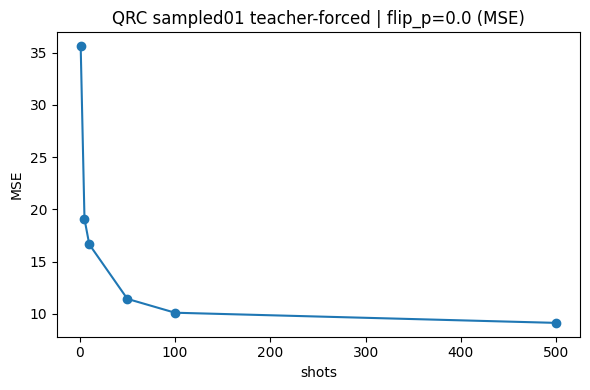

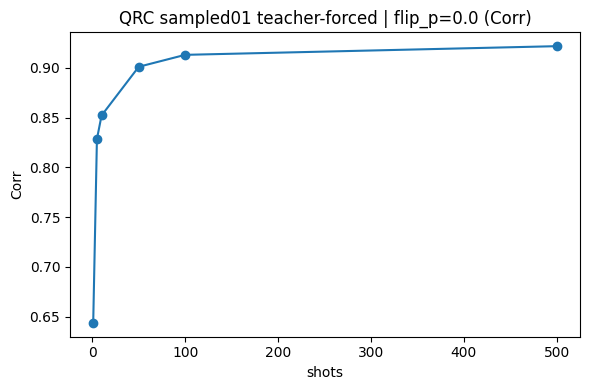

In [ ]:
res_sweep_clean = sweep_shots_qrc_teacher_forced(
    x_series,
    N=1, start_t=1000, T=1000, seed=43,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots_list=[1, 5, 10, 50, 100, 500],
    flip_p=0.0,
)

show_sweep_result_table_and_plot(
    res_sweep_clean,
    title="QRC sampled01 teacher-forced | flip_p=0.0"
)

shots= 1 | flip_p=0.000 | MSE=10.6994 | Corr=0.907828
shots= 5 | flip_p=0.000 | MSE=4.16889 | Corr=0.965134
shots=10 | flip_p=0.000 | MSE=3.22099 | Corr=0.973171
shots=50 | flip_p=0.000 | MSE=2.12388 | Corr=0.982392
shots=100 | flip_p=0.000 | MSE=1.89153 | Corr=0.984333
shots=500 | flip_p=0.000 | MSE=1.78297 | Corr=0.985239

=== sweep result ===
QRC sampled01 teacher-forced | flip_p=0.0
shots | mse        | corr
----- | ---------- | ----------
    1 |    10.6994 |   0.907828
    5 |    4.16889 |   0.965134
   10 |    3.22099 |   0.973171
   50 |    2.12388 |   0.982392
  100 |    1.89153 |   0.984333
  500 |    1.78297 |   0.985239


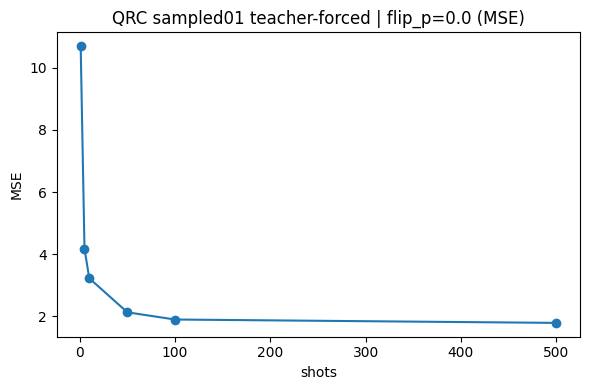

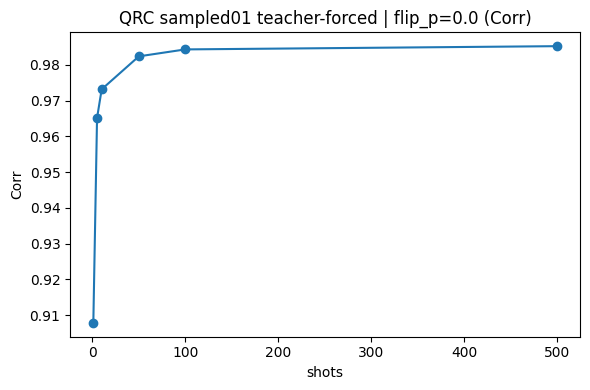

In [ ]:
res_sweep_clean = sweep_shots_qrc_teacher_forced(
    x_series,
    N=10, start_t=1000, T=1000, seed=43,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots_list=[1, 5, 10, 50, 100, 500],
    flip_p=0.0,
)

show_sweep_result_table_and_plot(
    res_sweep_clean,
    title="QRC sampled01 teacher-forced | flip_p=0.0"
)

shots= 1 | flip_p=0.000 | MSE=1.16183e-05 | Corr=1
shots= 5 | flip_p=0.000 | MSE=0.000105744 | Corr=0.999999
shots=10 | flip_p=0.000 | MSE=0.000128938 | Corr=0.999999
shots=50 | flip_p=0.000 | MSE=0.000602712 | Corr=0.999995
shots=100 | flip_p=0.000 | MSE=0.000604359 | Corr=0.999995
shots=500 | flip_p=0.000 | MSE=0.00131493 | Corr=0.999989
shots=1000 | flip_p=0.000 | MSE=0.00117382 | Corr=0.99999
shots=5000 | flip_p=0.000 | MSE=0.000687828 | Corr=0.999994

=== sweep result ===
QRC sampled01 teacher-forced | flip_p=0.0
shots | mse        | corr
----- | ---------- | ----------
    1 | 1.16183e-05 |          1
    5 | 0.000105744 |   0.999999
   10 | 0.000128938 |   0.999999
   50 | 0.000602712 |   0.999995
  100 | 0.000604359 |   0.999995
  500 | 0.00131493 |   0.999989
 1000 | 0.00117382 |    0.99999
 5000 | 0.000687828 |   0.999994


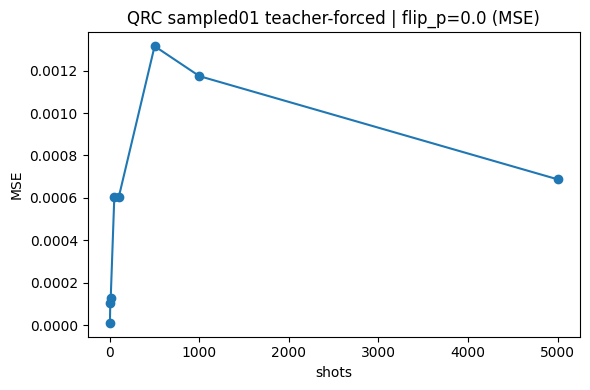

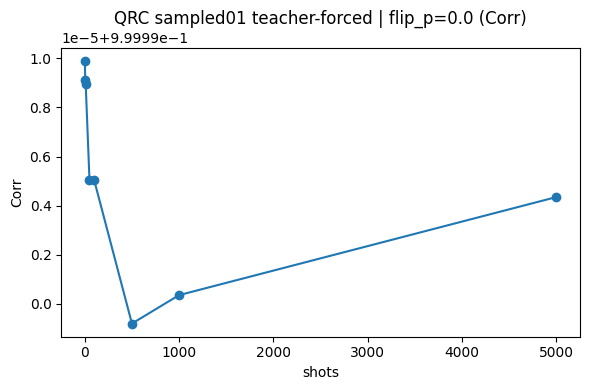

In [ ]:
res_sweep_clean = sweep_shots_qrc_teacher_forced(
    x_series,
    N=100, start_t=1000, T=1000, seed=43,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots_list=[1, 5, 10, 50, 100, 500, 1000, 5000],
    flip_p=0.0,
)

show_sweep_result_table_and_plot(
    res_sweep_clean,
    title="QRC sampled01 teacher-forced | flip_p=0.0"
)

shots= 1 | flip_p=0.075 | MSE=3.28343e-06 | Corr=1
shots= 5 | flip_p=0.075 | MSE=1.5602e-05 | Corr=1
shots=10 | flip_p=0.075 | MSE=4.59953e-05 | Corr=1
shots=50 | flip_p=0.075 | MSE=0.00021977 | Corr=0.999998
shots=100 | flip_p=0.075 | MSE=0.000516874 | Corr=0.999996
shots=500 | flip_p=0.075 | MSE=0.000662202 | Corr=0.999995
shots=1000 | flip_p=0.075 | MSE=0.000792311 | Corr=0.999993
shots=5000 | flip_p=0.075 | MSE=0.00126464 | Corr=0.99999
shots=10000 | flip_p=0.075 | MSE=0.000610357 | Corr=0.999995

=== sweep result ===
QRC sampled01 teacher-forced | flip_p=0.075
shots | mse        | corr
----- | ---------- | ----------
    1 | 3.28343e-06 |          1
    5 | 1.5602e-05 |          1
   10 | 4.59953e-05 |          1
   50 | 0.00021977 |   0.999998
  100 | 0.000516874 |   0.999996
  500 | 0.000662202 |   0.999995
 1000 | 0.000792311 |   0.999993
 5000 | 0.00126464 |    0.99999
10000 | 0.000610357 |   0.999995


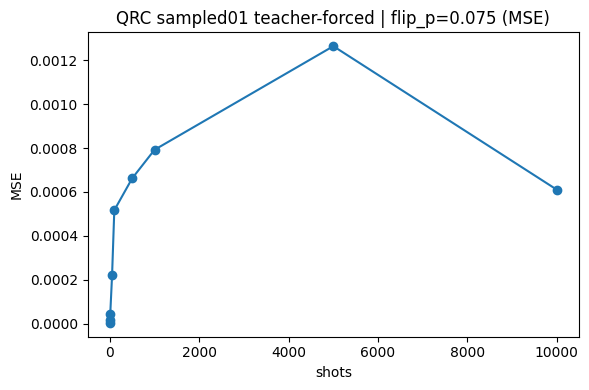

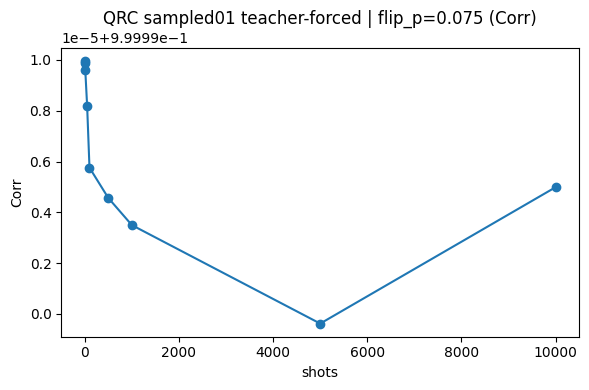

In [ ]:
res_sweep_clean = sweep_shots_qrc_teacher_forced(
    x_series,
    N=100, start_t=1000, T=1000, seed=43,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots_list=[1, 5, 10, 50, 100, 500, 1000, 5000, 10000],
    flip_p=0.075,
)

show_sweep_result_table_and_plot(
    res_sweep_clean,
    title="QRC sampled01 teacher-forced | flip_p=0.075"
)

shots= 1 | flip_p=0.000 | MSE=1.71434e-10 | Corr=1
shots= 5 | flip_p=0.000 | MSE=1.344e-09 | Corr=1
shots=10 | flip_p=0.000 | MSE=2.79782e-09 | Corr=1
shots=50 | flip_p=0.000 | MSE=7.42881e-09 | Corr=1
shots=100 | flip_p=0.000 | MSE=8.70263e-09 | Corr=1
shots=500 | flip_p=0.000 | MSE=9.62908e-09 | Corr=1
shots=1000 | flip_p=0.000 | MSE=1.04805e-08 | Corr=1
shots=5000 | flip_p=0.000 | MSE=1.09287e-08 | Corr=1

=== sweep result ===
QRC sampled01 teacher-forced | flip_p=0.0
shots | mse        | corr
----- | ---------- | ----------
    1 | 1.71434e-10 |          1
    5 |  1.344e-09 |          1
   10 | 2.79782e-09 |          1
   50 | 7.42881e-09 |          1
  100 | 8.70263e-09 |          1
  500 | 9.62908e-09 |          1
 1000 | 1.04805e-08 |          1
 5000 | 1.09287e-08 |          1


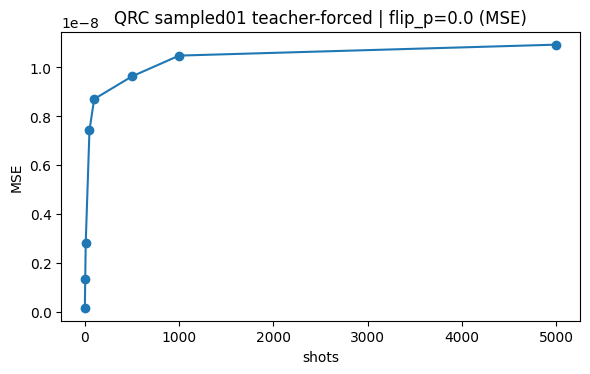

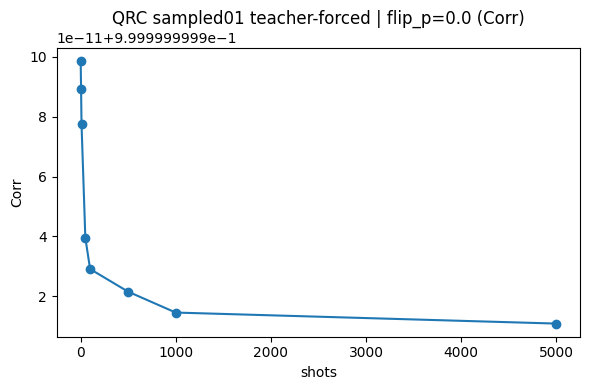

In [ ]:
res_sweep_clean = sweep_shots_qrc_teacher_forced(
    x_series,
    N=1000, start_t=1000, T=1000, seed=43,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots_list=[1, 5, 10, 50, 100, 500, 1000, 5000],
    flip_p=0.0,
)

show_sweep_result_table_and_plot(
    res_sweep_clean,
    title="QRC sampled01 teacher-forced | flip_p=0.0"
)

**seed値を変えた時の性能比較**

(1-4)

[QRC sampled01 clean]   MSE=0.000012  Corr=1.000000
[QRC sampled01 flip7.5] MSE=0.000003  Corr=1.000000


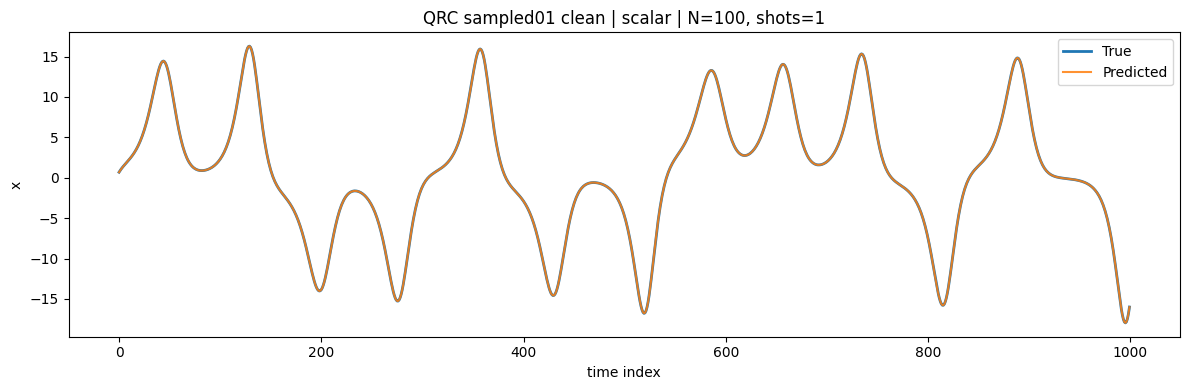

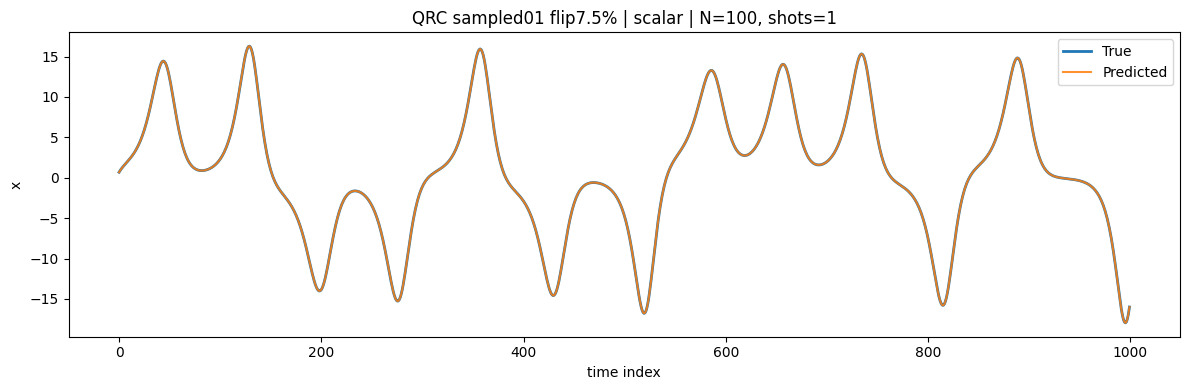

QRC MSE mean/std/min/max: 3.226205091485977e-06 7.282108341845422e-07 1.854686934044752e-06 4.8780548305990545e-06
QRC Corr mean/std/min/max: 0.9999999738657075 5.894982978207962e-09 0.9999999606317737 0.9999999849907463


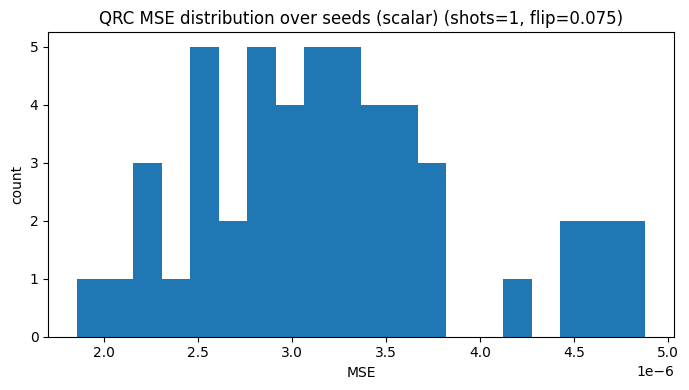

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
start_t = 1000
T = 1000
seed = 43

# (A) ノイズなし（shots平均だけ）
res_clean = qrc_teacher_forced_eval_sampled01_scalar(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=1,
    flip_p=0.0
)

# (B) フリップ7.5%
res_flip = qrc_teacher_forced_eval_sampled01_scalar(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=1,
    flip_p=0.075
)

print(f"[QRC sampled01 clean]   MSE={res_clean['mse']:.6f}  Corr={res_clean['corr']:.6f}")
print(f"[QRC sampled01 flip7.5] MSE={res_flip['mse']:.6f}  Corr={res_flip['corr']:.6f}")

# タイトルの shots 表記も実際に合わせて 1 にしておくのが安全
plot_true_vs_pred(res_clean["Y"], res_clean["Yhat"], title=f"QRC sampled01 clean | scalar | N={N}, shots=1")
plot_true_vs_pred(res_flip["Y"],  res_flip["Yhat"],  title=f"QRC sampled01 flip7.5% | scalar | N={N}, shots=1")


def eval_many_seeds_qrc_scalar(
    x_series, *,
    seeds, N=100, start_t=1000, T=1000,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2, norm_const=1.0,
    sign_mode="plus", input_mode="scale",
    shots=1, flip_p=0.075,
):
    mses, corrs = [], []
    for seed in seeds:
        res = qrc_teacher_forced_eval_sampled01_scalar(
            x_series,
            N=N, start_t=start_t, T=T, seed=int(seed),
            alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            ridge=ridge, norm_const=norm_const,
            sign_mode=sign_mode, input_mode=input_mode,
            shots=shots, flip_p=flip_p
        )
        mses.append(res["mse"]); corrs.append(res["corr"])
    return np.array(mses), np.array(corrs)


seeds = np.arange(0, 50) + 100  # 50本
mses, corrs = eval_many_seeds_qrc_scalar(
    x_series, seeds=seeds,
    N=100, start_t=1000, T=1000,
    shots=1, flip_p=0.075
)

print("QRC MSE mean/std/min/max:", mses.mean(), mses.std(), mses.min(), mses.max())
print("QRC Corr mean/std/min/max:", corrs.mean(), corrs.std(), corrs.min(), corrs.max())

plt.figure(figsize=(7,4))
plt.hist(mses, bins=20)
plt.title("QRC MSE distribution over seeds (scalar) (shots=1, flip=0.075)")
plt.xlabel("MSE"); plt.ylabel("count"); plt.tight_layout(); plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# -------------------------
# データセット: 入力 U=x(t), 教師 Y=x(t+1)
# -------------------------
def make_scalar_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 0:
        raise ValueError("start_t must be >= 0")
    if start_t + T + 1 > len(x):
        raise ValueError("range out of x_series (need t+1)")
    U = x[start_t : start_t + T]                 # (T,)
    Y = x[start_t + 1 : start_t + T + 1]         # (T,)
    return U, Y

# -------------------------
# 共通: ridge readout（bias付き、biasは正則化しない）
# -------------------------
def fit_readout_ridge(S: np.ndarray, Y: np.ndarray, ridge: float = 1e-2) -> Tuple[np.ndarray, float]:
    S = np.asarray(S, float)
    Y = np.asarray(Y, float).reshape(-1)
    T, M = S.shape
    if Y.size != T:
        raise ValueError("S and Y length mismatch")

    X = np.hstack([S, np.ones((T, 1))])  # (T, M+1)
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))  # biasは正則化しない
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)
    w = theta[:M]
    b = float(theta[M])
    return w, b

def predict_readout(S: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    return np.asarray(S, float) @ np.asarray(w, float) + float(b)

def mse_corr(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    y_true = np.asarray(y_true, float).reshape(-1)
    y_pred = np.asarray(y_pred, float).reshape(-1)
    mse = float(np.mean((y_true - y_pred) ** 2))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    return mse, corr

def plot_true_vs_pred(y_true, y_pred, title=""):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label="True", lw=2)
    plt.plot(y_pred, label="Predicted", lw=1.5, alpha=0.85)
    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================================================
# (A) QRC: 0/1サンプリング + flip + shots平均（スカラー入力）
# =========================================================
def simulate_qrc_states_sampled01_scalar(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U: np.ndarray,              # (T,) スカラー入力
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",    # "pm" or "plus"
    input_mode: str = "scale",  # "scale" or "replace"
    Win: Optional[np.ndarray] = None,   # (1,M)
    Win_scale: float = 1.0,
    carry_state: bool = True,
    shots: int = 10,
    flip_p: float = 0.0,        # 測定反転確率
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      S:  (T,M)  shots平均した0/1検出（=検出率推定）
      xT: (M,)   最終状態（無励起確率として保持）
    """
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]
    U1 = U.reshape(T, 1)  # (T,1)

    M = 12 * N
    rng = np.random.default_rng(seed)

    # 入力マスク (1,M)  ※10→1
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, float)
        if Win.shape != (1, M):
            raise ValueError(f"Win must be (1,{M})")

    # 状態（無励起確率）
    x_state = np.zeros(M, dtype=float)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    shots = max(1, int(shots))
    flip_p = float(flip_p)
    if not (0.0 <= flip_p <= 0.5):
        raise ValueError("flip_p must be in [0,0.5]")

    for t in range(T):
        # スカラー → M次元入力
        u_vec = U1[t] @ Win  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入
        p = np.clip(x_state, 0.0, 1.0)      # 無励起確率
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)          # Trueなら励起

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ ネットワーク（以降そのまま）
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / sqrt2

        # ⑧ 非線形（安全版）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        # ---- 0/1測定（shots回） + flip ----
        draws = (rng.random((shots, M)) < out_prob[None, :]).astype(np.int8)
        if flip_p > 0.0:
            flips = (rng.random((shots, M)) < flip_p).astype(np.int8)
            draws = draws ^ flips

        out_mean = draws.mean(axis=0).astype(float)  # (M,)
        S[t] = out_mean

        if carry_state:
            x_state = np.clip(1.0 - out_mean, 0.0, 1.0)

    return S, x_state

# =========================================================
# (B) 決定論的 ESN (tanh)：スカラー入力版
# =========================================================
def simulate_esn_states_tanh_scalar(
    M: int,
    U: np.ndarray,  # (T,) スカラー入力
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]
    rng = np.random.default_rng(seed)

    # Win: (1,M)
    Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(input_scale)

    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)
    eigvals = np.linalg.eigvals(Wres)
    sr = np.max(np.abs(eigvals)) + 1e-12
    Wres = Wres * (float(spectral_radius) / sr)

    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)

    leak = float(leak_rate)
    for t in range(T):
        pre = x @ Wres + np.array([U[t]]) @ Win + b
        x_new = np.tanh(pre)
        x = (1.0 - leak) * x + leak * x_new
        S[t] = x

    params = {"Wres": Wres, "Win": Win, "b": b}
    return S, params

# =========================================================
# 比較：QRC sampled01+flip vs ESN tanh（スカラー入力）
# =========================================================
def compare_qrc_sampled01_vs_esn_scalar(
    x_series: np.ndarray,
    *,
    N: int = 100,
    start_t: int = 1000,
    T: int = 1000,
    seed: int = 43,
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    shots: int = 10,
    flip_p: float = 0.0,
    ridge: float = 1e-2,
    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    U, Y = make_scalar_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    # --- QRC
    S_qrc, _ = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
    Yhat_qrc = predict_readout(S_qrc, wq, bq)
    mse_qrc, corr_qrc = mse_corr(Y, Yhat_qrc)

    # --- ESN
    S_esn, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn, Y, ridge=ridge)
    Yhat_esn = predict_readout(S_esn, we, be)
    mse_esn, corr_esn = mse_corr(Y, Yhat_esn)

    print(f"[QRC sampled01] M={M} shots={shots} flip={flip_p:.3f}  MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN tanh]     M={M}                        MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")

    plot_true_vs_pred(Y, Yhat_qrc, title=f"QRC sampled01 Teacher-forced 1-step | scalar | N={N}, M={M}, shots={shots}, flip={flip_p:.3f}")
    plot_true_vs_pred(Y, Yhat_esn, title=f"ESN (tanh) Teacher-forced 1-step | scalar | M={M}")

    return {
        "Y": Y,
        "Yhat_qrc": Yhat_qrc,
        "Yhat_esn": Yhat_esn,
        "metrics": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        }
    }

[QRC sampled01] M=1200 shots=1 flip=0.075  MSE=0.000003  Corr=1.000000
[ESN tanh]     M=1200                        MSE=0.000192  Corr=0.999998


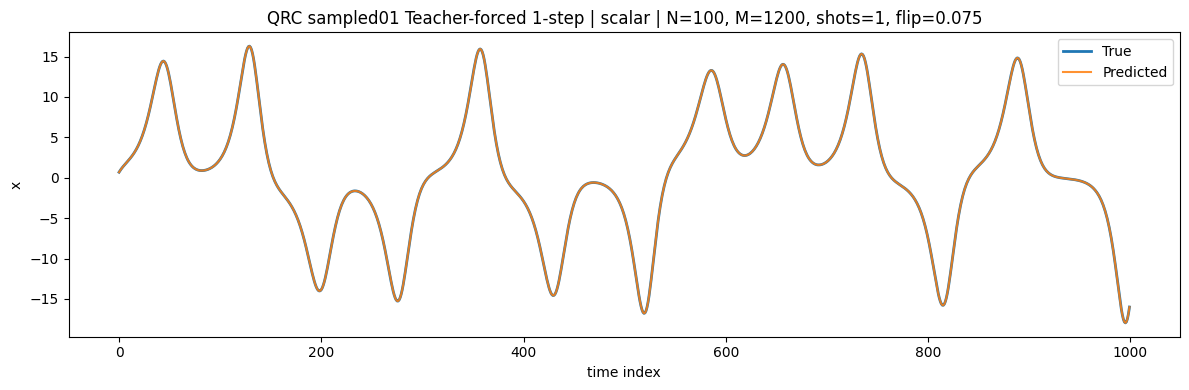

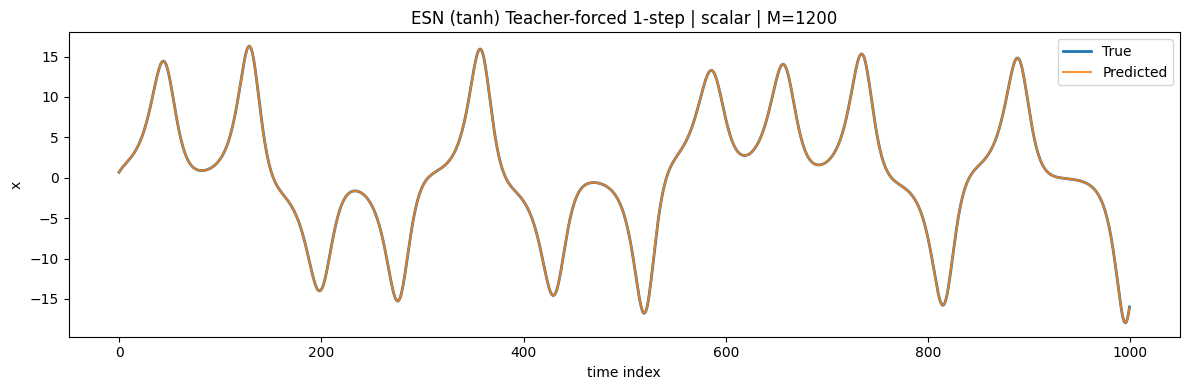

In [ ]:
res = compare_qrc_sampled01_vs_esn_scalar(
    x_series,
    N=100, start_t=1000, T=1000, seed=43,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    shots=1, flip_p=0.075,
    ridge=1e-2,
    spectral_radius=0.9, input_scale_esn=0.5, leak_rate=1.0, bias_scale=0.1,
)

In [ ]:
import numpy as np
from typing import Tuple, Optional, Dict
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# データセット: 入力 U=x(t), 教師 Y=x(t+1)
# ------------------------------------------------------------
def make_scalar_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 0:
        raise ValueError("start_t must be >= 0")
    if start_t + T + 1 > len(x):
        raise ValueError("range out of x_series (need t+1)")
    U = x[start_t : start_t + T]                 # (T,)
    Y = x[start_t + 1 : start_t + T + 1]         # (T,)
    return U, Y

# ------------------------------------------------------------
# ESN: 決定論状態 x(t) を作る（通常の ESN）※スカラー入力版
# ------------------------------------------------------------
def simulate_esn_states_tanh_scalar(
    M: int,
    U: np.ndarray,  # (T,)
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]
    rng = np.random.default_rng(seed)

    # Win: (1,M)
    Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(input_scale)

    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)
    eigvals = np.linalg.eigvals(Wres)
    sr = np.max(np.abs(eigvals)) + 1e-12
    Wres = Wres * (float(spectral_radius) / sr)

    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)

    leak = float(leak_rate)
    for t in range(T):
        pre = x @ Wres + np.array([U[t]]) @ Win + b
        x_new = np.tanh(pre)
        x = (1.0 - leak) * x + leak * x_new
        S[t] = x

    params = {"Wres": Wres, "Win": Win, "b": b}
    return S, params

# ------------------------------------------------------------
# ESN: 「QRCと同型」の測定ノイズをかける（同じ）
# ------------------------------------------------------------
def esn_measurement_sampled01(
    x_det: np.ndarray,
    *,
    seed: int = 43,
    shots: int = 1,
    flip_p: float = 0.0,
    prob_map: str = "affine",   # "affine" or "sigmoid"
    sigmoid_k: float = 1.0,
) -> np.ndarray:
    x_det = np.asarray(x_det, float)
    if x_det.ndim != 2:
        raise ValueError("x_det must be (T,M)")
    T, M = x_det.shape

    rng = np.random.default_rng(seed)
    shots = max(1, int(shots))
    flip_p = float(flip_p)
    if not (0.0 <= flip_p <= 0.5):
        raise ValueError("flip_p must be in [0,0.5]")

    if prob_map == "affine":
        p = 0.5 * (x_det + 1.0)
    elif prob_map == "sigmoid":
        p = 1.0 / (1.0 + np.exp(-float(sigmoid_k) * x_det))
    else:
        raise ValueError('prob_map must be "affine" or "sigmoid"')

    p = np.clip(p, 0.0, 1.0)

    draws = (rng.random((shots, T, M)) < p[None, :, :]).astype(np.int8)

    if flip_p > 0.0:
        flips = (rng.random((shots, T, M)) < flip_p).astype(np.int8)
        draws = draws ^ flips

    z = draws.mean(axis=0).astype(float)
    return z

# ------------------------------------------------------------
# ESN + 測定ノイズ込みの状態列（スカラー入力版）
# ------------------------------------------------------------
def simulate_esn_states_sampled01_scalar(
    M: int,
    U: np.ndarray,   # (T,)
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
    shots: int = 1,
    flip_p: float = 0.0,
    prob_map: str = "affine",
    sigmoid_k: float = 1.0,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    x_det, params = simulate_esn_states_tanh_scalar(
        M=M, U=U,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    z = esn_measurement_sampled01(
        x_det,
        seed=seed + 99991,
        shots=shots,
        flip_p=flip_p,
        prob_map=prob_map,
        sigmoid_k=sigmoid_k,
    )
    params = dict(params)
    params.update({"prob_map": prob_map, "sigmoid_k": sigmoid_k, "shots": shots, "flip_p": flip_p})
    return z, params


# ------------------------------------------------------------
# QRC vs ESN（同じ測定ノイズ）※スカラー入力版
#  - ここでは、あなたが既に用意した
#    simulate_qrc_states_sampled01_scalar, fit_readout_ridge,
#    predict_readout, mse_corr, plot_true_vs_pred
#    が存在する前提です（前の回答のやつ）
# ------------------------------------------------------------
def compare_qrc_vs_esn_with_same_measurement_noise_scalar(
    x_series,
    *,
    N=100,
    start_t=1000,
    T=1000,
    seed=43,
    ridge=1e-2,
    # measurement
    shots=1,
    flip_p=0.075,
    # ESN core
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
    prob_map="affine",
    sigmoid_k=1.0,
    # QRC params（スカラー版を呼ぶ）
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win_scale_qrc=1.0,
    carry_state=True,
):
    # 1) データセット（スカラー）
    U, Y = make_scalar_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    # 2) QRC states（スカラー版）
    S_qrc, _ = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
    Yhat_qrc = predict_readout(S_qrc, wq, bq)
    mse_qrc, corr_qrc = mse_corr(Y, Yhat_qrc)

    # 3) ESN states + same measurement noise（スカラー）
    S_esn_noisy, _ = simulate_esn_states_sampled01_scalar(
        M=M, U=U,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
        shots=shots,
        flip_p=flip_p,
        prob_map=prob_map,
        sigmoid_k=sigmoid_k,
    )
    we, be = fit_readout_ridge(S_esn_noisy, Y, ridge=ridge)
    Yhat_esn = predict_readout(S_esn_noisy, we, be)
    mse_esn, corr_esn = mse_corr(Y, Yhat_esn)

    print(f"[QRC sampled01]   M={M} shots={shots} flip={flip_p:.3f}  MSE={mse_qrc:.6e}  Corr={corr_qrc:.9f}")
    print(f"[ESN + same meas] M={M} shots={shots} flip={flip_p:.3f}  MSE={mse_esn:.6e}  Corr={corr_esn:.9f}  (prob_map={prob_map})")

    plot_true_vs_pred(Y, Yhat_qrc, title=f"QRC (scalar) | shots={shots}, flip={flip_p:.3f}")
    plot_true_vs_pred(Y, Yhat_esn, title=f"ESN (scalar) + same measurement noise | shots={shots}, flip={flip_p:.3f}, map={prob_map}")

    return {
        "metrics": {"qrc": (mse_qrc, corr_qrc), "esn_noisy": (mse_esn, corr_esn)},
        "Y": Y, "Yhat_qrc": Yhat_qrc, "Yhat_esn": Yhat_esn
    }

[QRC sampled01]   M=1200 shots=1 flip=0.075  MSE=3.283429e-06  Corr=0.999999973
[ESN + same meas] M=1200 shots=1 flip=0.075  MSE=1.414692e-06  Corr=0.999999988  (prob_map=affine)


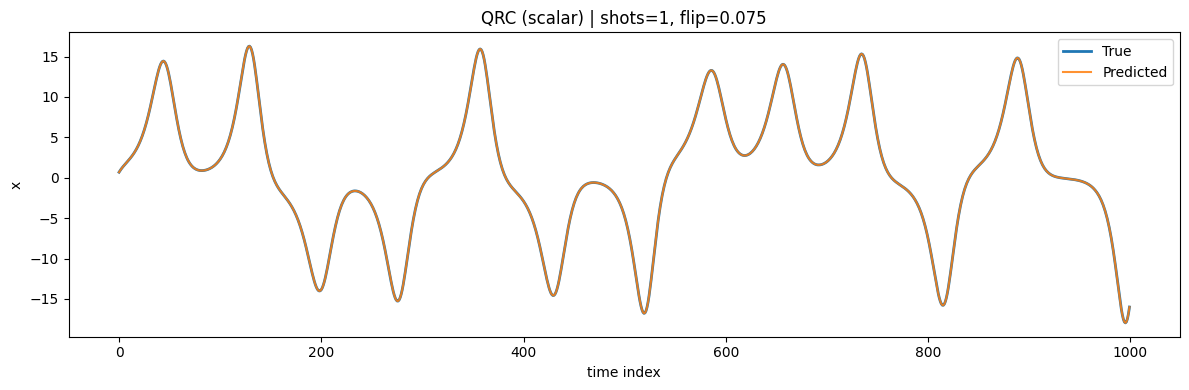

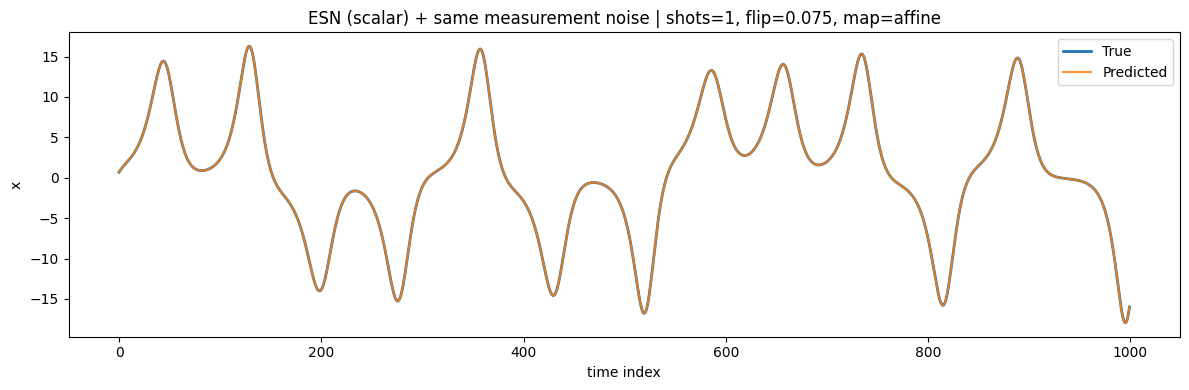

In [ ]:
 res = compare_qrc_vs_esn_with_same_measurement_noise_scalar(
     x_series,
     N=100, start_t=1000, T=1000, seed=43,
     shots=1, flip_p=0.075,
     prob_map="affine"
 )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def summarize(arr):
    arr = np.asarray(arr, float)
    return {
        "mean": float(np.mean(arr)),
        "std":  float(np.std(arr, ddof=1)),
        "min":  float(np.min(arr)),
        "max":  float(np.max(arr)),
    }

def plot_overlaid_hist(q_mse, e_mse, title="MSE distribution over seeds"):
    plt.figure(figsize=(9,4))
    plt.hist(q_mse, bins=25, alpha=0.6, label="QRC", density=True)
    plt.hist(e_mse, bins=25, alpha=0.6, label="ESN (+same meas noise)", density=True)
    plt.title(title)
    plt.xlabel("MSE")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_scatter(q_mse, e_mse, title="Per-seed MSE: QRC vs ESN"):
    plt.figure(figsize=(5,5))
    plt.scatter(e_mse, q_mse, alpha=0.8)
    mn = min(np.min(e_mse), np.min(q_mse))
    mx = max(np.max(e_mse), np.max(q_mse))
    plt.plot([mn, mx], [mn, mx], "--")
    plt.xlabel("ESN MSE")
    plt.ylabel("QRC MSE")
    plt.title(title + "\n(below diagonal = QRC better)")
    plt.tight_layout()
    plt.show()

def paired_tests(q_mse, e_mse):
    q_mse = np.asarray(q_mse, float)
    e_mse = np.asarray(e_mse, float)
    diff = e_mse - q_mse  # +ならESNが悪い（QRCが良い）

    t_stat, p_two = stats.ttest_rel(e_mse, q_mse)
    dz = float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-12))  # Cohen's dz

    return {
        "mean_diff(ESN-QRC)": float(np.mean(diff)),
        "std_diff": float(np.std(diff, ddof=1)),
        "t_stat": float(t_stat),
        "p_val_two_sided": float(p_two),
        "cohens_dz": dz,
        "fraction_QRC_better": float(np.mean(q_mse < e_mse)),
    }


def seed_sweep_qrc_vs_esn_scalar(
    x_series,
    seeds,
    *,
    N=100,
    start_t=1000,
    T=1000,
    ridge=1e-2,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0, sign_mode="plus", input_mode="scale",
    Win_scale_qrc=1.0, carry_state=True,
    shots=1, flip_p=0.075,
    # ESN core
    spectral_radius=0.9, input_scale_esn=0.5, leak_rate=1.0, bias_scale=0.1,
    prob_map="affine", sigmoid_k=1.0,
):
    # スカラー入力: U=x(t), Y=x(t+1)
    U, Y = make_scalar_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    q_mse, q_corr = [], []
    e_mse, e_corr = [], []

    for sd in seeds:
        sd = int(sd)

        # --- QRC (scalar) ---
        S_qrc, _ = simulate_qrc_states_sampled01_scalar(
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            U=U,
            seed=sd,
            norm_const=norm_const,
            sign_mode=sign_mode,
            input_mode=input_mode,
            Win=None,
            Win_scale=Win_scale_qrc,
            carry_state=carry_state,
            shots=shots,
            flip_p=flip_p,
        )
        wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
        Yhat_q = predict_readout(S_qrc, wq, bq)
        mse_q, corr_q = mse_corr(Y, Yhat_q)
        q_mse.append(mse_q); q_corr.append(corr_q)

        # --- ESN (+same measurement noise) (scalar) ---
        S_esn_noisy, _ = simulate_esn_states_sampled01_scalar(
            M=M, U=U,
            seed=sd,
            spectral_radius=spectral_radius,
            input_scale=input_scale_esn,
            leak_rate=leak_rate,
            bias_scale=bias_scale,
            shots=shots,
            flip_p=flip_p,
            prob_map=prob_map,
            sigmoid_k=sigmoid_k,
        )
        we, be = fit_readout_ridge(S_esn_noisy, Y, ridge=ridge)
        Yhat_e = predict_readout(S_esn_noisy, we, be)
        mse_e, corr_e = mse_corr(Y, Yhat_e)
        e_mse.append(mse_e); e_corr.append(corr_e)

    return (np.array(q_mse), np.array(q_corr)), (np.array(e_mse), np.array(e_corr))

=== QRC (scalar) ===
MSE: {'mean': 3.226205091485977e-06, 'std': 7.356040271220033e-07, 'min': 1.854686934044752e-06, 'max': 4.8780548305990545e-06}
Corr: {'mean': 0.9999999738657075, 'std': 5.954832055528742e-09, 'min': 0.9999999606317737, 'max': 0.9999999849907463}

=== ESN (+same measurement noise) (scalar) ===
MSE: {'mean': 1.1054975489162506e-06, 'std': 2.2742888747496486e-07, 'min': 6.734291051945076e-07, 'max': 1.6940858025275715e-06}
Corr: {'mean': 0.9999999909485561, 'std': 1.8621601716163988e-09, 'min': 0.999999986135605, 'max': 0.9999999944878795}

=== Paired test (per-seed) ===
{'mean_diff(ESN-QRC)': -2.1207075425697257e-06, 'std_diff': 6.96023184853356e-07, 't_stat': -21.544780646645464, 'p_val_two_sided': 1.2127455634128286e-26, 'cohens_dz': -3.0468877213175194, 'fraction_QRC_better': 0.0}


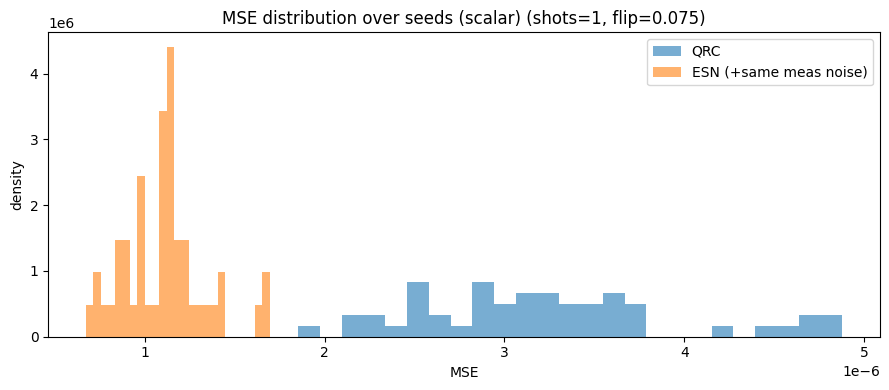

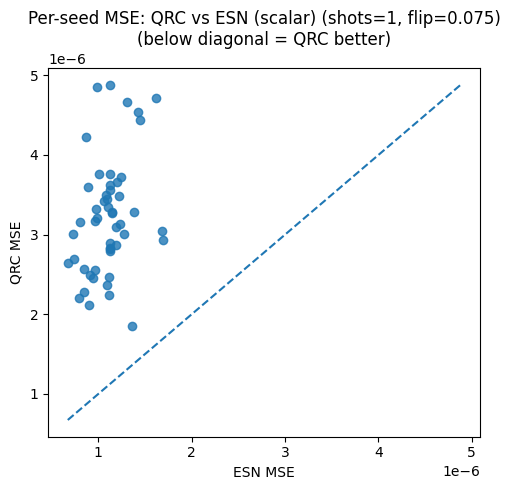

In [ ]:
seeds = np.arange(50) + 100  # 例：50 seeds
(q_mse, q_corr), (e_mse, e_corr) = seed_sweep_qrc_vs_esn_scalar(
    x_series, seeds,
    N=100, start_t=1000, T=1000,
    shots=1, flip_p=0.075,
    prob_map="affine",
)

print("=== QRC (scalar) ===")
print("MSE:", summarize(q_mse))
print("Corr:", summarize(q_corr))

print("\n=== ESN (+same measurement noise) (scalar) ===")
print("MSE:", summarize(e_mse))
print("Corr:", summarize(e_corr))

print("\n=== Paired test (per-seed) ===")
print(paired_tests(q_mse, e_mse))

plot_overlaid_hist(q_mse, e_mse, title="MSE distribution over seeds (scalar) (shots=1, flip=0.075)")
plot_scatter(q_mse, e_mse, title="Per-seed MSE: QRC vs ESN (scalar) (shots=1, flip=0.075)")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# QRC: out_prob（平均版）で状態列 S(T,M) を作る（スカラー入力）
#  - 10次元窓の代わりに U=x(t) を使う
#  - shots/flipは使わない（out_probをそのまま状態にする）
# -----------------------------
def simulate_qrc_states_meanprob_scalar(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U: np.ndarray,                 # (T,)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: np.ndarray | None = None,  # (1,M)
    Win_scale: float = 1.0,
    carry_state: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]
    U1 = U.reshape(T, 1)  # (T,1)

    M = 12 * N
    rng = np.random.default_rng(seed)

    # Win: (1,M)  ※10→1
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, float)
        if Win.shape != (1, M):
            raise ValueError(f"Win must be (1,{M})")

    x_state = np.zeros(M, dtype=float)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # 入力 スカラー→M次元
        u_vec = U1[t] @ Win  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ ネットワーク（そのまま）
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / sqrt2

        # ⑧ out_prob（安全版）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    return S, x_state


# -----------------------------
# 統計＆描画ユーティリティ（そのまま）
# -----------------------------
def summarize(arr):
    arr = np.asarray(arr, float)
    return {
        "mean": float(np.mean(arr)),
        "std":  float(np.std(arr, ddof=1)),
        "min":  float(np.min(arr)),
        "max":  float(np.max(arr)),
    }

def paired_test(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    diff = b - a
    t, p = stats.ttest_rel(b, a)
    dz = float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-12))
    return {
        "mean_diff(b-a)": float(np.mean(diff)),
        "std_diff": float(np.std(diff, ddof=1)),
        "t_stat": float(t),
        "p_two_sided": float(p),
        "cohens_dz": dz,
        "frac_a_better": float(np.mean(a < b)),
    }

def plot_hist_overlay(series_dict, title, xlabel="MSE"):
    plt.figure(figsize=(10,4))
    for name, arr in series_dict.items():
        plt.hist(arr, bins=25, alpha=0.55, density=True, label=name)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_scatter_xy(x, y, title, xlabel, ylabel):
    x = np.asarray(x, float); y = np.asarray(y, float)
    plt.figure(figsize=(5,5))
    plt.scatter(x, y, alpha=0.8)
    mn = min(np.min(x), np.min(y))
    mx = max(np.max(x), np.max(y))
    plt.plot([mn,mx],[mn,mx],"--")
    plt.title(title + "\n(below diagonal means y < x)")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 4本同時 seed sweep（スカラー入力版）
#   QRC meanprob / QRC sampled / ESN cont / ESN sampled
# -----------------------------
def sweep_4ways_scalar(
    x_series,
    seeds,
    *,
    N=100,
    start_t=1000,
    T=1000,
    ridge=1e-2,
    # QRC params
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0, sign_mode="plus", input_mode="scale",
    Win_scale_qrc=1.0, carry_state=True,
    shots=1, flip_p=0.075,
    # ESN params
    spectral_radius=0.9, input_scale_esn=0.5, leak_rate=1.0, bias_scale=0.1,
    prob_map="affine", sigmoid_k=1.0,
):
    # スカラー入力: U=x(t), Y=x(t+1)
    U, Y = make_scalar_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    mse_q_mean, corr_q_mean = [], []
    mse_q_samp, corr_q_samp = [], []

    mse_e_cont, corr_e_cont = [], []
    mse_e_samp, corr_e_samp = [], []

    for sd in seeds:
        sd = int(sd)

        # --- QRC meanprob (scalar) ---
        S_q_mean, _ = simulate_qrc_states_meanprob_scalar(
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            U=U,
            seed=sd,
            norm_const=norm_const,
            sign_mode=sign_mode,
            input_mode=input_mode,
            Win=None,
            Win_scale=Win_scale_qrc,
            carry_state=carry_state,
        )
        w, b = fit_readout_ridge(S_q_mean, Y, ridge=ridge)
        Yhat = predict_readout(S_q_mean, w, b)
        mse, corr = mse_corr(Y, Yhat)
        mse_q_mean.append(mse); corr_q_mean.append(corr)

        # --- QRC sampled01+flip (scalar) ---
        S_q_samp, _ = simulate_qrc_states_sampled01_scalar(
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            U=U,
            seed=sd,
            norm_const=norm_const,
            sign_mode=sign_mode,
            input_mode=input_mode,
            Win=None,
            Win_scale=Win_scale_qrc,
            carry_state=carry_state,
            shots=shots,
            flip_p=flip_p,
        )
        w, b = fit_readout_ridge(S_q_samp, Y, ridge=ridge)
        Yhat = predict_readout(S_q_samp, w, b)
        mse, corr = mse_corr(Y, Yhat)
        mse_q_samp.append(mse); corr_q_samp.append(corr)

        # --- ESN continuous (scalar) ---
        S_e_cont, _ = simulate_esn_states_tanh_scalar(
            M=M, U=U,
            seed=sd,
            spectral_radius=spectral_radius,
            input_scale=input_scale_esn,
            leak_rate=leak_rate,
            bias_scale=bias_scale,
        )
        w, b = fit_readout_ridge(S_e_cont, Y, ridge=ridge)
        Yhat = predict_readout(S_e_cont, w, b)
        mse, corr = mse_corr(Y, Yhat)
        mse_e_cont.append(mse); corr_e_cont.append(corr)

        # --- ESN sampled01+flip (same measurement noise) (scalar) ---
        S_e_samp, _ = simulate_esn_states_sampled01_scalar(
            M=M, U=U,
            seed=sd,
            spectral_radius=spectral_radius,
            input_scale=input_scale_esn,
            leak_rate=leak_rate,
            bias_scale=bias_scale,
            shots=shots,
            flip_p=flip_p,
            prob_map=prob_map,
            sigmoid_k=sigmoid_k,
        )
        w, b = fit_readout_ridge(S_e_samp, Y, ridge=ridge)
        Yhat = predict_readout(S_e_samp, w, b)
        mse, corr = mse_corr(Y, Yhat)
        mse_e_samp.append(mse); corr_e_samp.append(corr)

    out = {
        "QRC_mean": (np.array(mse_q_mean), np.array(corr_q_mean)),
        "QRC_samp": (np.array(mse_q_samp), np.array(corr_q_samp)),
        "ESN_cont": (np.array(mse_e_cont), np.array(corr_e_cont)),
        "ESN_samp": (np.array(mse_e_samp), np.array(corr_e_samp)),
    }
    return out

=== SUMMARY (MSE) ===
QRC mean : {'mean': 0.0011997838422208608, 'std': 0.00042950565344389475, 'min': 0.0005564252114467121, 'max': 0.0026396951768996204}
QRC samp : {'mean': 3.226205091485977e-06, 'std': 7.356040271220033e-07, 'min': 1.854686934044752e-06, 'max': 4.8780548305990545e-06}
ESN cont : {'mean': 0.00018222316427270326, 'std': 4.011044488937758e-05, 'min': 0.00010912934000703779, 'max': 0.0002633055337741591}
ESN samp : {'mean': 1.1054975489162506e-06, 'std': 2.2742888747496486e-07, 'min': 6.734291051945076e-07, 'max': 1.6940858025275715e-06}

=== SUMMARY (Corr) ===
QRC mean : {'mean': 0.9999901463047877, 'std': 3.5281361326019926e-06, 'min': 0.9999783186452869, 'max': 0.9999954311685508}
QRC samp : {'mean': 0.9999999738657075, 'std': 5.954832055528742e-09, 'min': 0.9999999606317737, 'max': 0.9999999849907463}
ESN cont : {'mean': 0.9999985025955254, 'std': 3.296019493043975e-07, 'min': 0.9999978363519219, 'max': 0.9999991032330906}
ESN samp : {'mean': 0.9999999909485561, 's

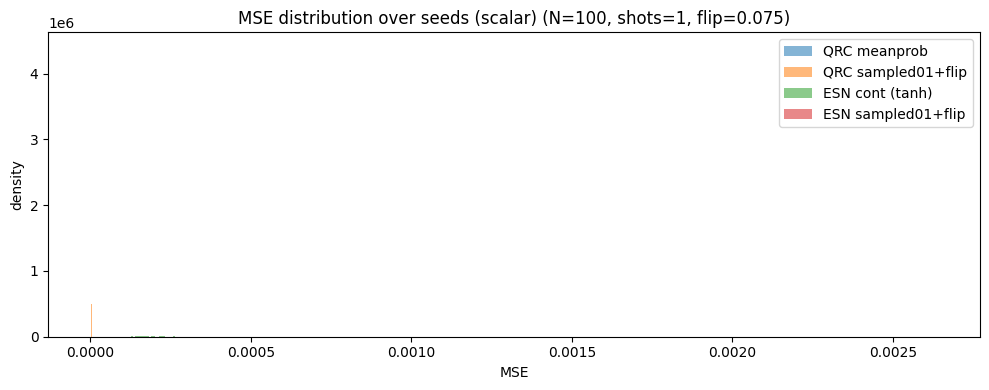


=== ΔMSE (measured - baseline) ===
QRC ΔMSE: {'mean': -0.0011965576371293749, 'std': 0.00042961618750675975, 'min': -0.0026361958052646063, 'max': -0.0005527614664127313}
ESN ΔMSE: {'mean': -0.000181117666723787, 'std': 4.004891868674342e-05, 'min': -0.00026217660492455693, 'max': -0.00010833041011102697}


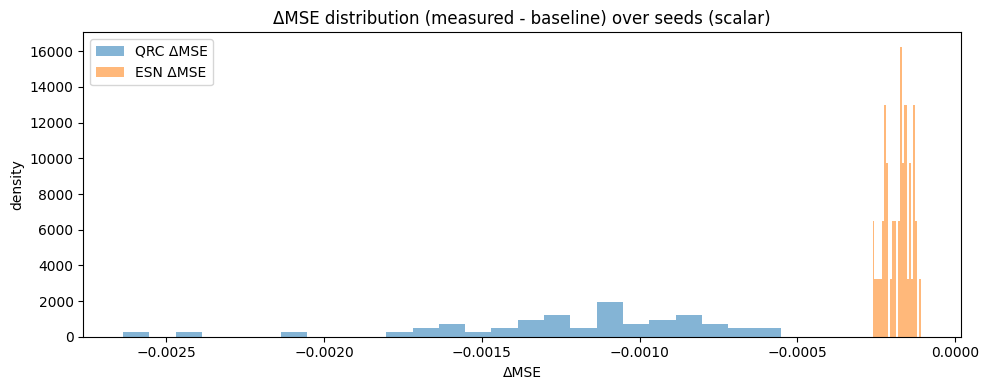


=== Paired test: baseline vs measured (MSE) ===
QRC: meanprob vs sampled01: {'mean_diff(b-a)': -0.0011965576371293749, 'std_diff': 0.00042961618750675975, 't_stat': -19.694183876193456, 'p_two_sided': 6.321019455626043e-25, 'cohens_dz': -2.7851781872752865, 'frac_a_better': 0.0}
ESN: cont    vs sampled01: {'mean_diff(b-a)': -0.000181117666723787, 'std_diff': 4.004891868674342e-05, 't_stat': -31.97827420380944, 'p_two_sided': 1.7309551290205729e-34, 'cohens_dz': -4.5224107951091295, 'frac_a_better': 0.0}

=== Paired test: QRC measured vs ESN measured (MSE) ===
{'mean_diff(b-a)': -2.1207075425697257e-06, 'std_diff': 6.96023184853356e-07, 't_stat': -21.544780646645464, 'p_two_sided': 1.2127455634128286e-26, 'cohens_dz': -3.0468877213175194, 'frac_a_better': 0.0}


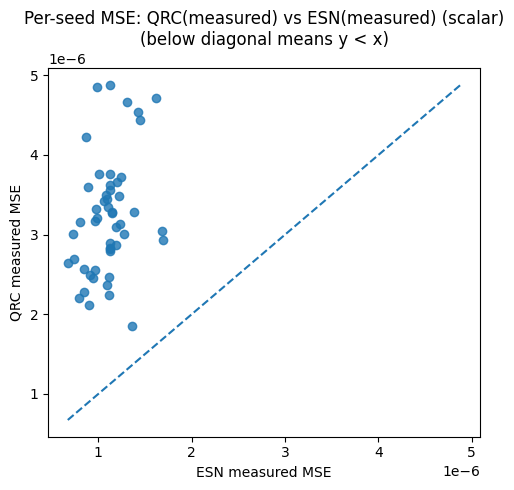

In [ ]:
seeds = np.arange(50) + 100
out = sweep_4ways_scalar(
    x_series, seeds,
    N=100, start_t=1000, T=1000,
    shots=1, flip_p=0.075,
    prob_map="affine",
)

m_q_mean, c_q_mean = out["QRC_mean"]
m_q_samp, c_q_samp = out["QRC_samp"]
m_e_cont, c_e_cont = out["ESN_cont"]
m_e_samp, c_e_samp = out["ESN_samp"]

print("=== SUMMARY (MSE) ===")
print("QRC mean :", summarize(m_q_mean))
print("QRC samp :", summarize(m_q_samp))
print("ESN cont :", summarize(m_e_cont))
print("ESN samp :", summarize(m_e_samp))

print("\n=== SUMMARY (Corr) ===")
print("QRC mean :", summarize(c_q_mean))
print("QRC samp :", summarize(c_q_samp))
print("ESN cont :", summarize(c_e_cont))
print("ESN samp :", summarize(c_e_samp))

plot_hist_overlay(
    {
        "QRC meanprob": m_q_mean,
        "QRC sampled01+flip": m_q_samp,
        "ESN cont (tanh)": m_e_cont,
        "ESN sampled01+flip": m_e_samp,
    },
    title=f"MSE distribution over seeds (scalar) (N={100}, shots=1, flip=0.075)"
)

dq = m_q_samp - m_q_mean
de = m_e_samp - m_e_cont

print("\n=== ΔMSE (measured - baseline) ===")
print("QRC ΔMSE:", summarize(dq))
print("ESN ΔMSE:", summarize(de))

plot_hist_overlay(
    {"QRC ΔMSE": dq, "ESN ΔMSE": de},
    title="ΔMSE distribution (measured - baseline) over seeds (scalar)",
    xlabel="ΔMSE"
)

print("\n=== Paired test: baseline vs measured (MSE) ===")
print("QRC: meanprob vs sampled01:", paired_test(m_q_mean, m_q_samp))
print("ESN: cont    vs sampled01:", paired_test(m_e_cont, m_e_samp))

print("\n=== Paired test: QRC measured vs ESN measured (MSE) ===")
print(paired_test(m_q_samp, m_e_samp))

plot_scatter_xy(
    m_e_samp, m_q_samp,
    title="Per-seed MSE: QRC(measured) vs ESN(measured) (scalar)",
    xlabel="ESN measured MSE",
    ylabel="QRC measured MSE",
)

100ステップ先予測

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# -------------------------
# データセット: 入力 U=x(t), 教師 Y=x(t+1)
# -------------------------
def make_scalar_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 0:
        raise ValueError("start_t must be >= 0")
    if start_t + T + 101 > len(x):
        raise ValueError("range out of x_series (need t+101)")
    U = x[start_t : start_t + T]                     # (T,)
    Y = x[start_t + 101 : start_t + T + 101]         # (T,)  ★ y[t+101]
    return U, Y

# -------------------------
# 共通: ridge readout（bias付き、biasは正則化しない）
# -------------------------
def fit_readout_ridge(S: np.ndarray, Y: np.ndarray, ridge: float = 1e-2) -> Tuple[np.ndarray, float]:
    S = np.asarray(S, float)
    Y = np.asarray(Y, float).reshape(-1)
    T, M = S.shape
    if Y.size != T:
        raise ValueError("S and Y length mismatch")
    X = np.hstack([S, np.ones((T, 1))])  # (T, M+1)
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))  # biasは正則化しない
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)
    w = theta[:M]
    b = float(theta[M])
    return w, b

def predict_readout(S: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    return np.asarray(S, float) @ np.asarray(w, float) + float(b)

def mse_corr(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    y_true = np.asarray(y_true, float).reshape(-1)
    y_pred = np.asarray(y_pred, float).reshape(-1)
    mse = float(np.mean((y_true - y_pred) ** 2))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    return mse, corr

def plot_true_vs_pred(y_true, y_pred, title=""):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label="True", lw=2)
    plt.plot(y_pred, label="Predicted", lw=1.5, alpha=0.85)
    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# (A) QRC: out_prob 状態列（入力はスカラー）
# =========================================================
def simulate_qrc_states_outprob_scalar(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U: np.ndarray,             # (T,)  スカラー入力
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",   # "pm" or "plus"
    input_mode: str = "scale", # "scale" or "replace"
    Win: Optional[np.ndarray] = None,     # (1,M)
    Win_scale: float = 1.0,
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      S: (T,M) out_prob（検出確率）状態列
      xT: (M,) 最終状態（無励起確率）
    """
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]
    U1 = U.reshape(T, 1)  # (T,1)

    M = 12 * N
    rng = np.random.default_rng(seed)

    # 入力マスク (1,M)  ※10→1の最小変更
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, float)
        if Win.shape != (1, M):
            raise ValueError(f"Win must be (1,{M})")

    # 状態（無励起確率）
    x_state = np.zeros(M, dtype=float)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # スカラー → M次元入力
        u_vec = (U1[t] @ Win)  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / np.sqrt(2.0)

        # ⑧ 非線形（安全版）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    return S, x_state


# =========================================================
# (B) 決定論的 ESN (tanh) ：同じ M=12N、入力はスカラー
# =========================================================
def simulate_esn_states_tanh_scalar(
    M: int,
    U: np.ndarray,  # (T,) スカラー入力
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    標準的 ESN:
      x_{t+1} = (1-leak)*x_t + leak*tanh( Wres x_t + Win u_t + b )
    Returns:
      S: (T,M) 状態列
      params: Wres, Win, b
    """
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]

    rng = np.random.default_rng(seed)

    # Win: (1,M)  ※10→1
    Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(input_scale)

    # Wres: (M,M) を作ってスペクトル半径調整
    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)

    eigvals = np.linalg.eigvals(Wres)
    sr = np.max(np.abs(eigvals)) + 1e-12
    Wres = Wres * (float(spectral_radius) / sr)

    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # u(t) はスカラーなので (1,) にしてから @ Win
        pre = x @ Wres + np.array([U[t]]) @ Win + b
        x_new = np.tanh(pre)
        x = (1.0 - leak_rate) * x + leak_rate * x_new
        S[t] = x

    params = {"Wres": Wres, "Win": Win, "b": b}
    return S, params


# =========================================================
# 実験: QRC vs ESN を同じ M で比較してプロット（スカラー入力）
# =========================================================
def compare_qrc_vs_esn_scalar(
    x_series: np.ndarray,
    *,
    N: int = 100,
    start_t: int = 1000,
    T: int = 1000,
    seed: int = 43,
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,
    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    U, Y = make_scalar_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    # --- QRC
    S_qrc, _ = simulate_qrc_states_outprob_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
    )
    wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
    Yhat_qrc = predict_readout(S_qrc, wq, bq)
    mse_qrc, corr_qrc = mse_corr(Y, Yhat_qrc)

    # --- ESN
    S_esn, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn, Y, ridge=ridge)
    Yhat_esn = predict_readout(S_esn, we, be)
    mse_esn, corr_esn = mse_corr(Y, Yhat_esn)

    print(f"[QRC] M={M}  MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN] M={M}  MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")

    plot_true_vs_pred(Y, Yhat_qrc, title=f"QRC (out_prob) Teacher-forced 1-step | scalar | N={N}, M={M}")
    plot_true_vs_pred(Y, Yhat_esn, title=f"ESN (tanh) Teacher-forced 1-step | scalar | M={M}")

    return {
        "Y": Y,
        "Yhat_qrc": Yhat_qrc,
        "Yhat_esn": Yhat_esn,
        "metrics": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        }
    }

[QRC] M=12  MSE=57.775014  Corr=0.261081
[ESN] M=12  MSE=52.472075  Corr=0.392082


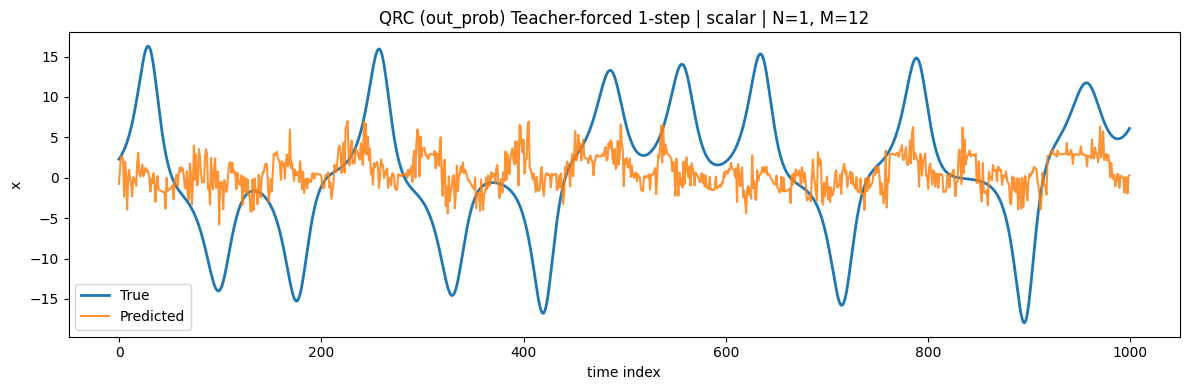

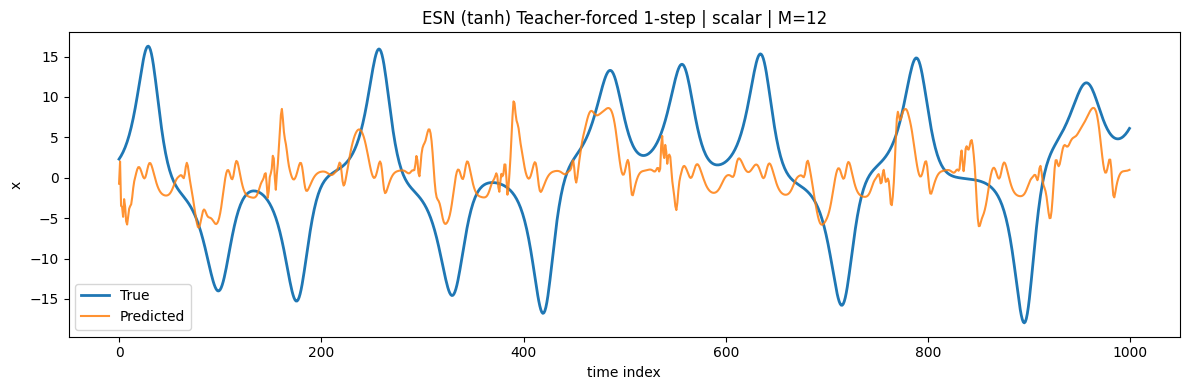

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=1,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=120  MSE=48.374937  Corr=0.468801
[ESN] M=120  MSE=43.074500  Corr=0.556955


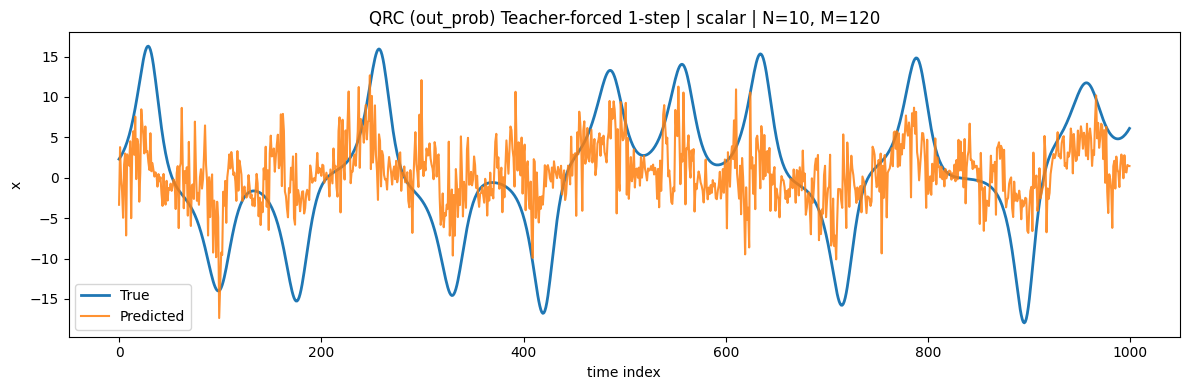

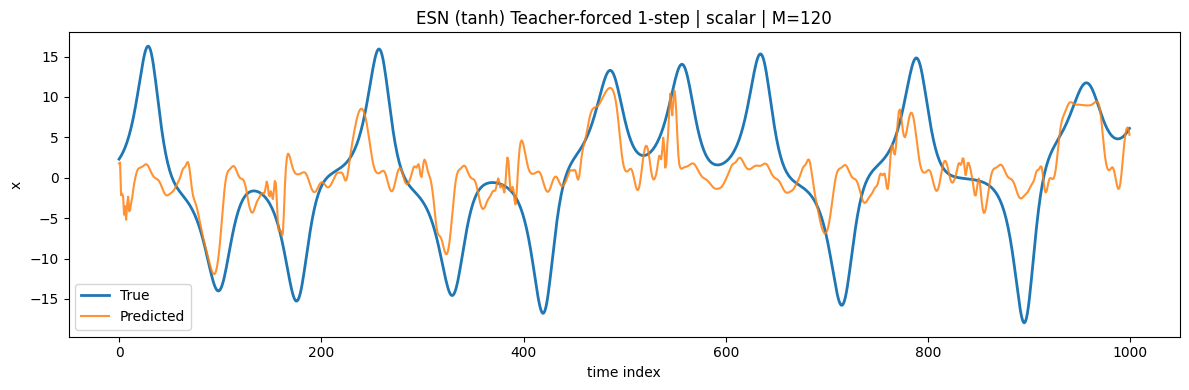

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=10,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=1200  MSE=0.116621  Corr=0.999103
[ESN] M=1200  MSE=31.142646  Corr=0.708857


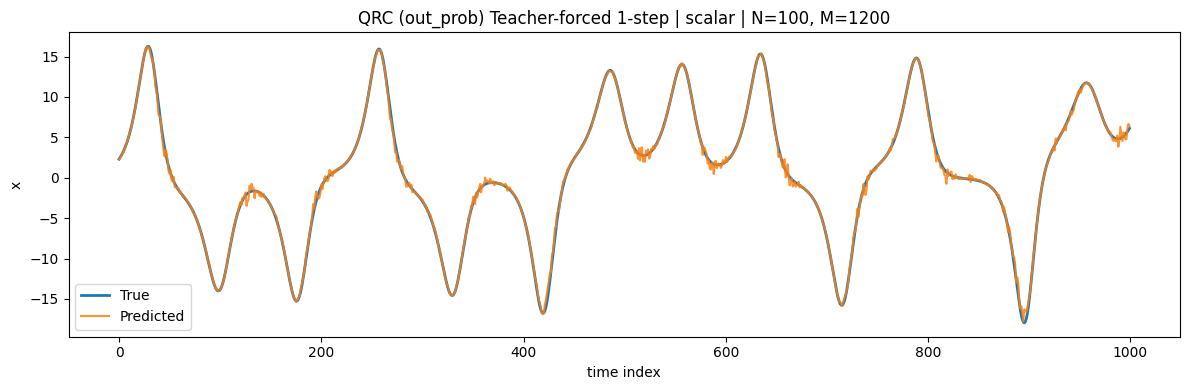

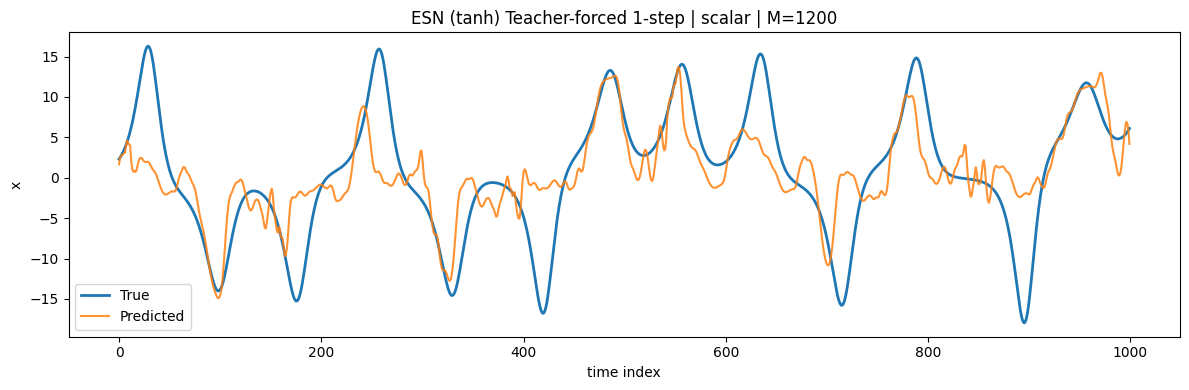

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=100,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

In [ ]:
# -------------------------
# データセット: 入力 U=x(t), 教師 Y=x(t+101)   ★ここだけ変更
# -------------------------
def make_scalar_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 0:
        raise ValueError("start_t must be >= 0")
    # ★ t+1001 が必要なので +1001 を要求
    if start_t + T + 1001 > len(x):
        raise ValueError("range out of x_series (need t+101)")
    U = x[start_t : start_t + T]                     # (T,)
    Y = x[start_t + 1001 : start_t + T + 1001]         # (T,)  ★ y[t+101]
    return U, Y

[QRC] M=12  MSE=59.289103  Corr=0.180919
[ESN] M=12  MSE=58.402757  Corr=0.217396


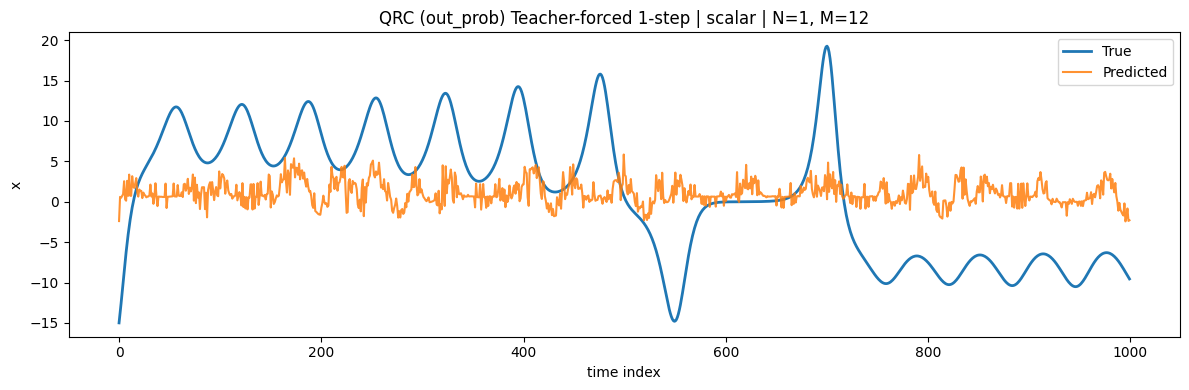

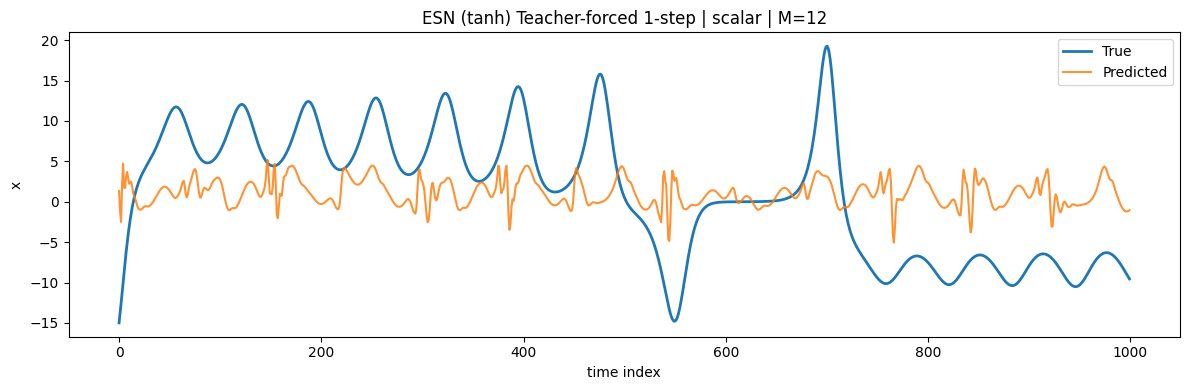

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=1,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=120  MSE=52.788438  Corr=0.372541
[ESN] M=120  MSE=41.766841  Corr=0.570323


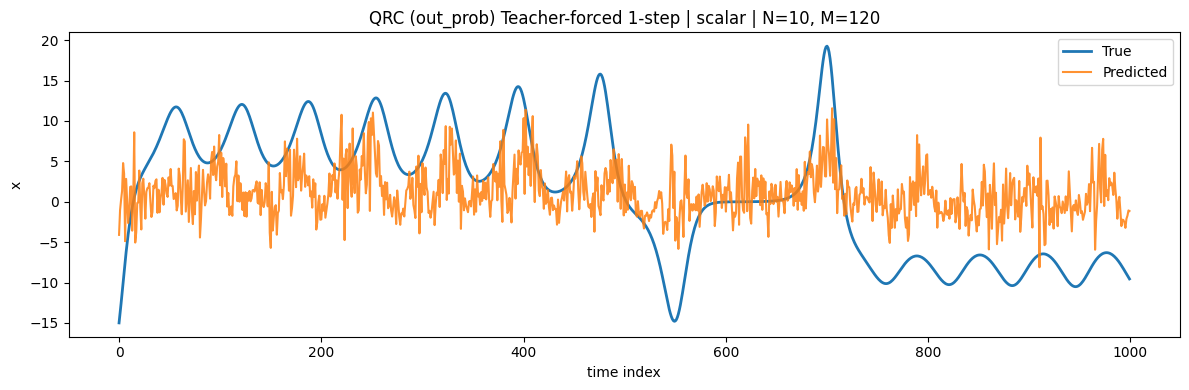

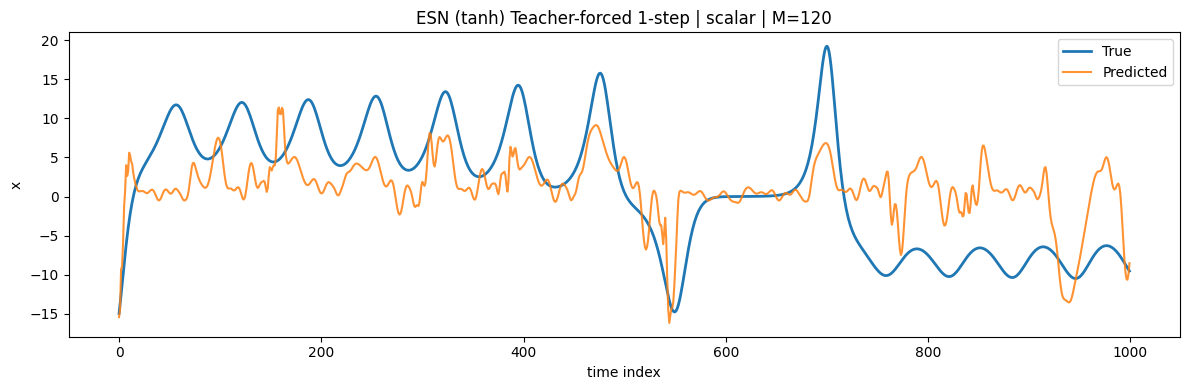

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=10,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=1200  MSE=1.276320  Corr=0.989977
[ESN] M=1200  MSE=54.866359  Corr=0.314900


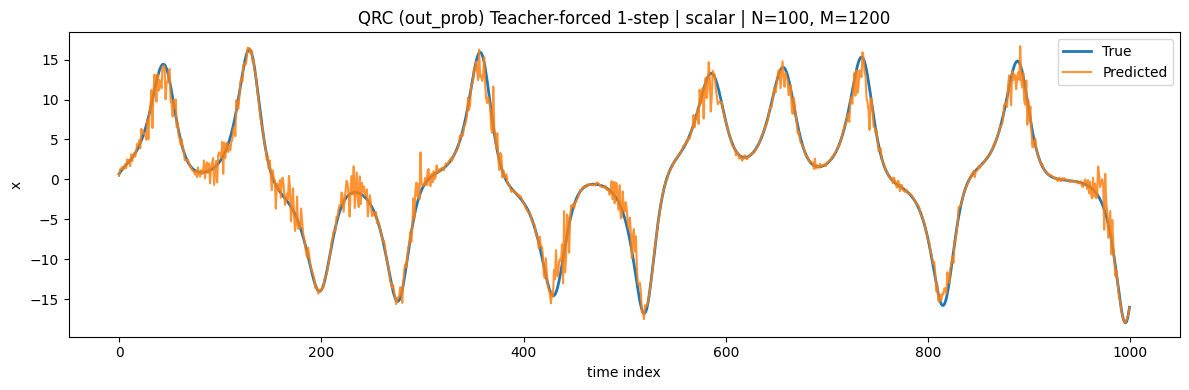

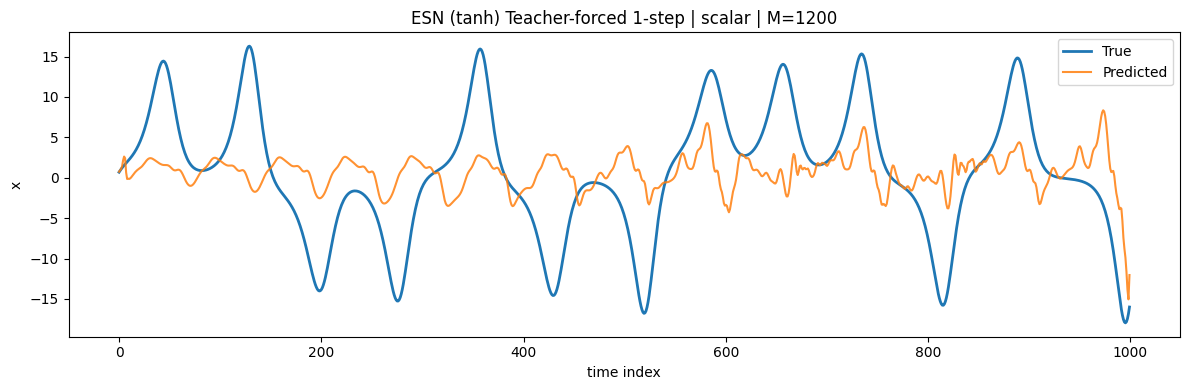

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=100,
    start_t=0,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=1200  MSE=0.220547  Corr=0.997912
[ESN] M=1200  MSE=36.474853  Corr=0.497398


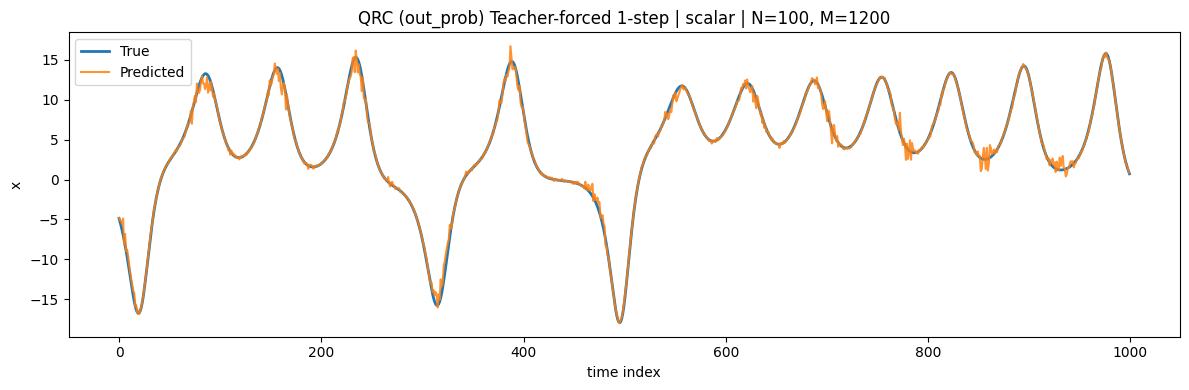

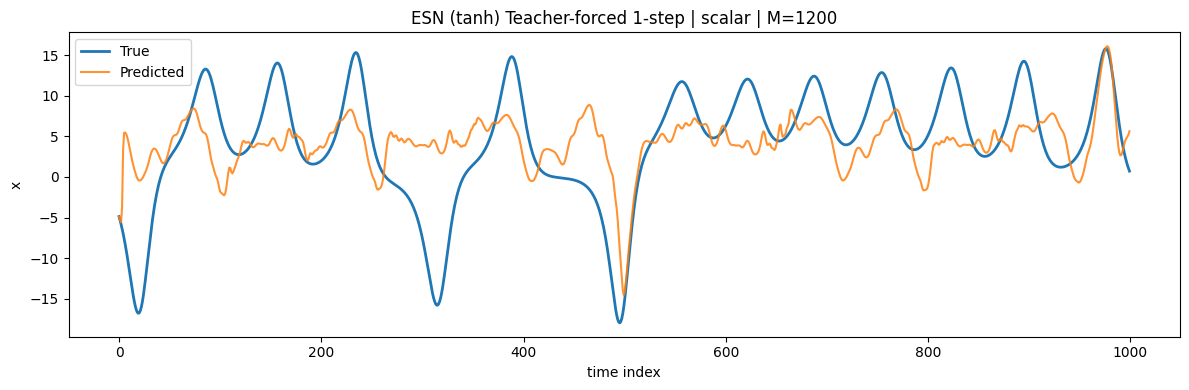

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=100,
    start_t=500,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=1200  MSE=0.109988  Corr=0.999159
[ESN] M=1200  MSE=27.273596  Corr=0.747322


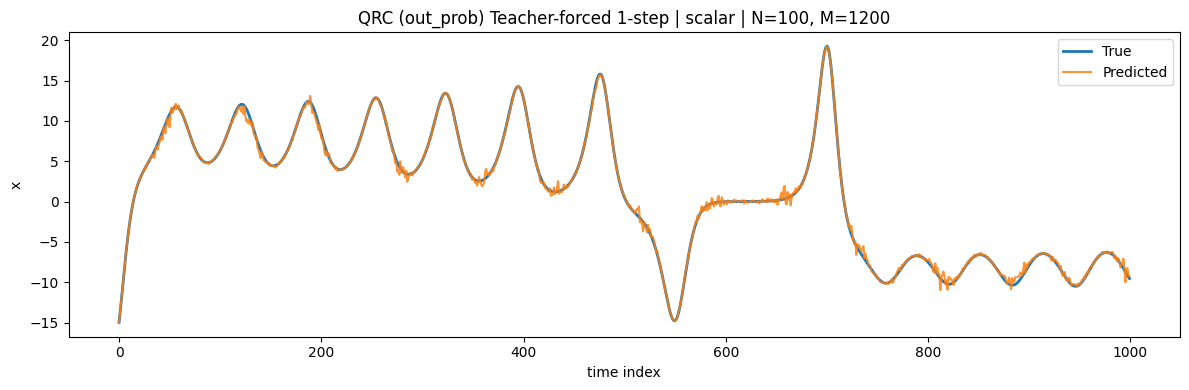

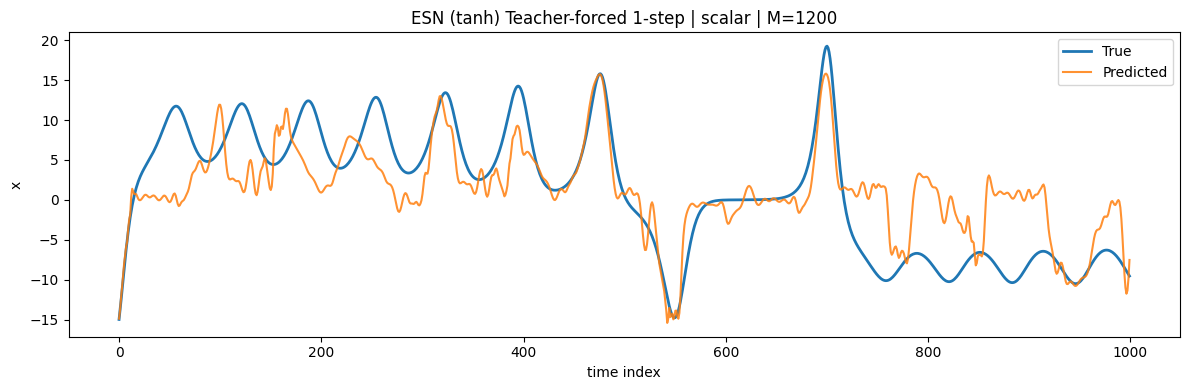

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=100,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=1200  MSE=0.222852  Corr=0.995702
[ESN] M=1200  MSE=15.400891  Corr=0.604348


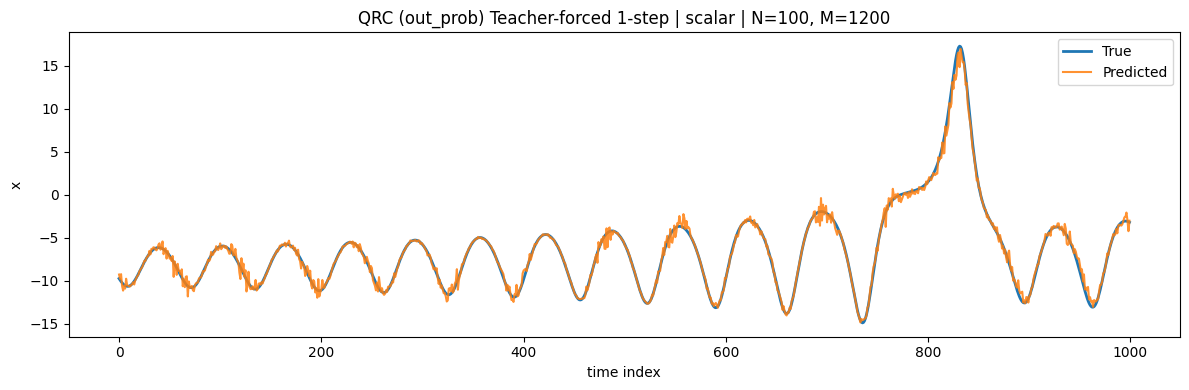

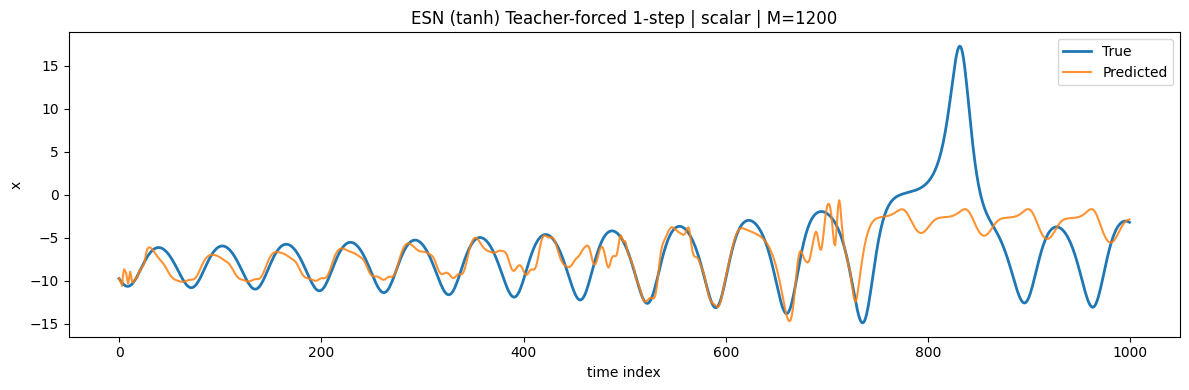

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn_scalar(
    x_series,
    N=100,
    start_t=2000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

→記憶を持たないものの、相関を細かく確率的に拾って、それを最後にランダム射影されたuによって一意に収束させることで、古典ESNより精度の高い予測ができる

**1000ステップ予測（オフライン学習、リッジ回帰）**

(1-5)

In [ ]:
def make_scalar_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 0:
        raise ValueError("start_t must be >= 0")
    # ★ 100ステップ先 = +101（あなたの指定どおり）
    if start_t + T + 101 > len(x):
        raise ValueError("range out of x_series (need t+101)")
    U = x[start_t : start_t + T]                     # (T,)
    Y = x[start_t + 101 : start_t + T + 101]         # (T,)  ★ y[t+101]
    return U, Y


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# =========================================================
# Trueは最初のTだけ、PredはT+Hまで描く（TrueはH以降NaNで線を切る）
# =========================================================
def plot_true_and_pred_with_tail(y_true_T, y_pred_TplusH, H, title=""):
    y_true_T = np.asarray(y_true_T, float).reshape(-1)
    y_pred_TplusH = np.asarray(y_pred_TplusH, float).reshape(-1)

    T = len(y_true_T)
    if len(y_pred_TplusH) != T + H:
        raise ValueError("length mismatch: y_pred must be T+H")

    # TrueはT以降をNaNにして描画を止める
    y_true_pad = np.concatenate([y_true_T, np.full(H, np.nan)])

    plt.figure(figsize=(12, 4))
    plt.plot(y_true_pad, label="True (available only up to T)", lw=2)
    plt.plot(y_pred_TplusH, label="Predicted (extended)", lw=1.5, alpha=0.85)
    plt.axvline(T - 1, linestyle="--", linewidth=1)  # ここまでが教師あり
    plt.title(title)
    plt.xlabel("time index (aligned to target x[t+101])")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 「教師ありT点」+「教師なしH点」まで予測する比較関数（スカラー入力）
# ※あなたの simulate_qrc_states_outprob_scalar / simulate_esn_states_tanh_scalar
#   fit_readout_ridge / predict_readout / mse_corr / make_scalar_dataset_next
#   をそのまま使います
# =========================================================
def compare_qrc_vs_esn_scalar_extend(
    x_series: np.ndarray,
    *,
    N: int = 1,
    start_t: int = 365,
    T: int = 1000,
    seed: int = 43,
    H: int = 101,  # ← ここが「教師なしで延長したい点数（=101）」、かつ学習の先読み幅も101想定
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,
    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    # -----------------------------
    # 1) 教師ありデータ（Y = x[t+101]）
    #    ※あなたが既に make_scalar_dataset_next を「+101版」に変更済みという前提
    # -----------------------------
    U_train, Y_train = make_scalar_dataset_next(x_series, start_t=start_t, T=T)

    # 教師なしで延長するには、入力がもうH点必要（U_extra = x[start_t+T : start_t+T+H]）
    x = np.asarray(x_series, float).reshape(-1)
    need_len = start_t + T + H  # 入力としてここまで必要（これが無いと延長できない）
    if need_len > len(x):
        raise ValueError(f"x_series is too short for tail forecast: need len >= {need_len}, got {len(x)}")

    U_all = x[start_t : start_t + T + H]  # (T+H,)

    M = 12 * N

    # -----------------------------
    # 2) QRC: 学習はT点、予測はT+H点
    # -----------------------------
    S_qrc_train, _ = simulate_qrc_states_outprob_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_train,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
    )
    wq, bq = fit_readout_ridge(S_qrc_train, Y_train, ridge=ridge)

    # 同じseedで「長い入力」を流して状態列を作り、T+H点ぶん予測
    S_qrc_all, _ = simulate_qrc_states_outprob_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_all,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
    )
    Yhat_qrc_all = predict_readout(S_qrc_all, wq, bq)  # (T+H,)

    # 教師あり部分の指標だけ計算
    mse_qrc, corr_qrc = mse_corr(Y_train, Yhat_qrc_all[:T])

    # -----------------------------
    # 3) ESN: 学習はT点、予測はT+H点
    # -----------------------------
    S_esn_train, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_train,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn_train, Y_train, ridge=ridge)

    S_esn_all, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_all,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    Yhat_esn_all = predict_readout(S_esn_all, we, be)  # (T+H,)

    mse_esn, corr_esn = mse_corr(Y_train, Yhat_esn_all[:T])

    print(f"[QRC] M={M}  (eval on first T only) MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN] M={M}  (eval on first T only) MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")
    print(f"Tail forecast length (no teacher): H={H}")

    # -----------------------------
    # 4) プロット：TrueはTまで、PredはT+Hまで
    # -----------------------------
    plot_true_and_pred_with_tail(
        Y_train, Yhat_qrc_all, H,
        title=f"QRC: predict x[t+101] (teacher-forced on T, then tail H) | N={N}, M={M}, H={H}"
    )
    plot_true_and_pred_with_tail(
        Y_train, Yhat_esn_all, H,
        title=f"ESN: predict x[t+101] (teacher-forced on T, then tail H) | M={M}, H={H}"
    )

    return {
        "Y_train": Y_train,
        "Yhat_qrc_all": Yhat_qrc_all,  # 長さ T+H（後ろHは教師なし）
        "Yhat_esn_all": Yhat_esn_all,  # 長さ T+H（後ろHは教師なし）
        "metrics_on_T": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        }
    }

[QRC] M=120  (eval on first T only) MSE=1.702762  Corr=0.984617
[ESN] M=120  (eval on first T only) MSE=0.000706  Corr=0.999994
Tail forecast length (no teacher): H=1001


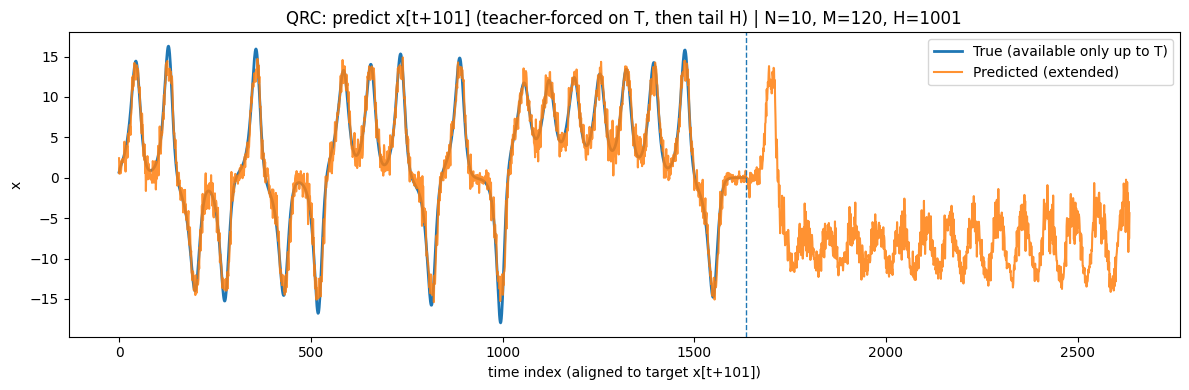

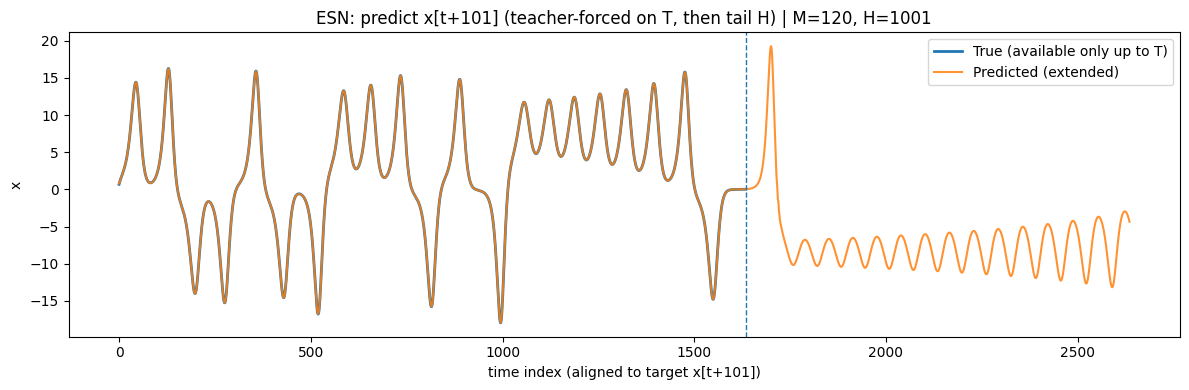

In [ ]:
res = compare_qrc_vs_esn_scalar_extend(
    lorenz_x_RK(6000),
    N=10,
    start_t=1000,
    T= len(lorenz_x_RK(3000)) - start_t - 1001,
    seed=43,
    H=1001,     # ここが「教師なしで延長する点数」
)

[QRC] M=1200  (eval on first T only) MSE=0.099362  Corr=0.999109
[ESN] M=1200  (eval on first T only) MSE=0.000130  Corr=0.999999
Tail forecast length (no teacher): H=1001


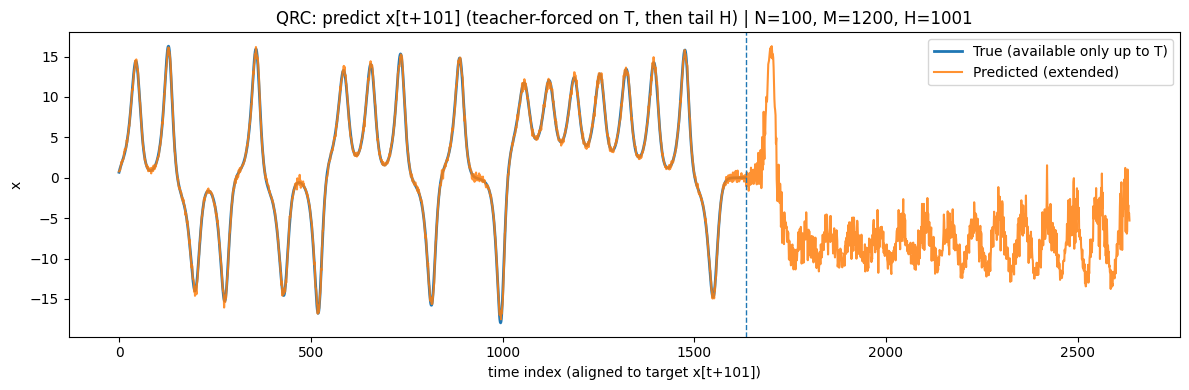

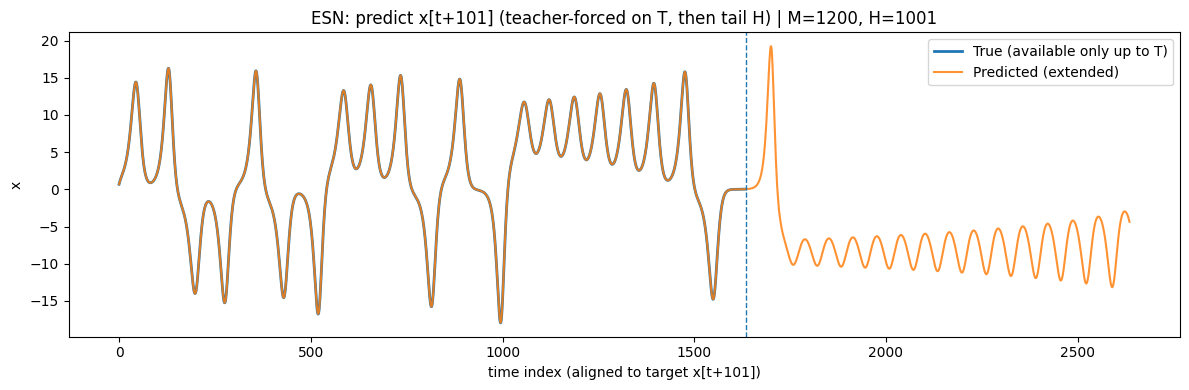

In [ ]:
res = compare_qrc_vs_esn_scalar_extend(
    lorenz_x_RK(6000),
    N=100,
    start_t=1000,
    T= len(lorenz_x_RK(3000)) - start_t - 1001,
    seed=43,
    H=1001,     # ここが「教師なしで延長する点数」
)

[QRC] M=12000  (eval on first T only) MSE=0.000000  Corr=1.000000
[ESN] M=12000  (eval on first T only) MSE=0.000013  Corr=1.000000
Tail forecast length (no teacher): H=1001


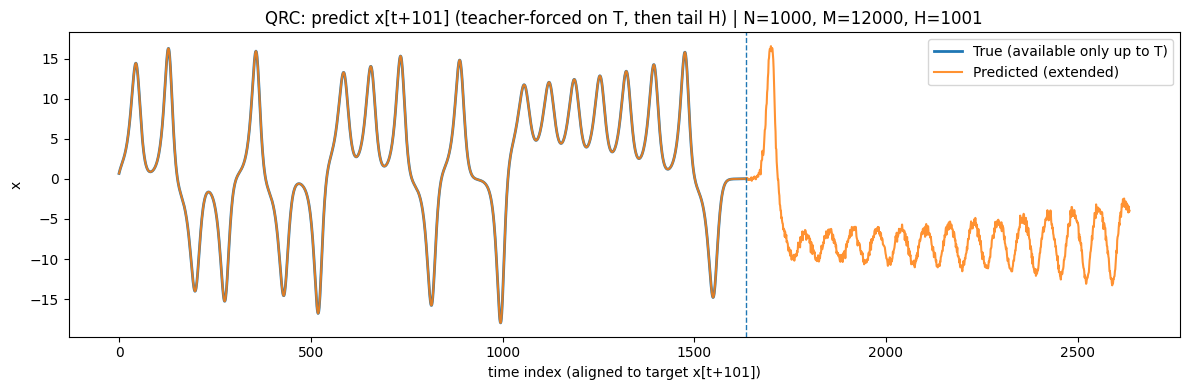

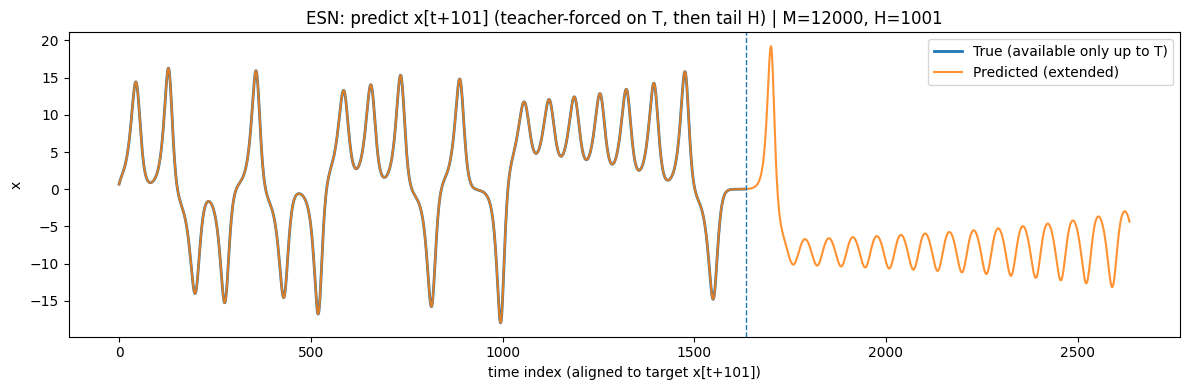

In [ ]:
res = compare_qrc_vs_esn_scalar_extend(
    lorenz_x_RK(6000),
    N=1000,
    start_t=1000,
    T= len(lorenz_x_RK(3000)) - start_t - 1001,
    seed=43,
    H=1001,     # ここが「教師なしで延長する点数」
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# =========================================================
# Trueは最初のTだけ、PredはT+Hまで描く（TrueはH以降NaNで線を切る）
# =========================================================
def plot_true_and_pred_with_tail(y_true_T, y_pred_TplusH, H, title=""):
    y_true_T = np.asarray(y_true_T, float).reshape(-1)
    y_pred_TplusH = np.asarray(y_pred_TplusH, float).reshape(-1)

    T = len(y_true_T)
    if len(y_pred_TplusH) != T + H:
        raise ValueError("length mismatch: y_pred must be T+H")

    # TrueはT以降をNaNにして描画を止める
    y_true_pad = np.concatenate([y_true_T, np.full(H, np.nan)])

    plt.figure(figsize=(12, 4))
    plt.plot(y_true_pad, label="True (available only up to T)", lw=2)
    plt.plot(y_pred_TplusH, label="Predicted (extended)", lw=1.5, alpha=0.85)
    plt.axvline(T - 1, linestyle="--", linewidth=1)  # ここまでが教師あり
    plt.title(title)
    plt.xlabel("time index (aligned to target x[t+101])")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 「教師ありT点」+「教師なしH点」まで予測する比較関数（スカラー入力）
# ★QRCの状態生成を simulate_qrc_states_sampled01_scalar に差し替え
# ※以下が既に定義済みという前提：
#   - make_scalar_dataset_next  (Y = x[t+101] 版)
#   - simulate_qrc_states_sampled01_scalar   ← これを使う
#   - simulate_esn_states_tanh_scalar
#   - fit_readout_ridge / predict_readout / mse_corr
# =========================================================
def compare_qrc_vs_esn_scalar_extend_sampled01(
    x_series: np.ndarray,
    *,
    N: int = 1,
    start_t: int = 365,
    T: int = 1000,
    seed: int = 43,
    H: int = 101,  # 教師なしで延長したい点数（=101）
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,
    # ★追加：QRC measurement (sampled01 + flip)
    shots: int = 1,
    flip_p: float = 0.0,
    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    # -----------------------------
    # 1) 教師ありデータ（Y = x[t+101]）
    # -----------------------------
    U_train, Y_train = make_scalar_dataset_next(x_series, start_t=start_t, T=T)

    # 教師なしで延長するには入力がもうH点必要（U_extra）
    x = np.asarray(x_series, float).reshape(-1)
    need_len = start_t + T + H  # 入力としてここまで必要
    if need_len > len(x):
        raise ValueError(f"x_series is too short for tail forecast: need len >= {need_len}, got {len(x)}")

    U_all = x[start_t : start_t + T + H]  # (T+H,)
    M = 12 * N

    # -----------------------------
    # 2) QRC: 学習はT点、予測はT+H点
    #    ★simulate_qrc_states_sampled01_scalar を使う
    # -----------------------------
    # 学習用状態列（T点）
    S_qrc_train, _, = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_train,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    wq, bq = fit_readout_ridge(S_qrc_train, Y_train, ridge=ridge)

    # 予測用状態列（T+H点）
    S_qrc_all, _, = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_all,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    Yhat_qrc_all = predict_readout(S_qrc_all, wq, bq)  # (T+H,)

    # 指標は教師あり部分（最初のT点）のみ
    mse_qrc, corr_qrc = mse_corr(Y_train, Yhat_qrc_all[:T])

    # -----------------------------
    # 3) ESN: 学習はT点、予測はT+H点（従来どおり）
    # -----------------------------
    S_esn_train, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_train,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn_train, Y_train, ridge=ridge)

    S_esn_all, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_all,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    Yhat_esn_all = predict_readout(S_esn_all, we, be)  # (T+H,)

    mse_esn, corr_esn = mse_corr(Y_train, Yhat_esn_all[:T])

    print(f"[QRC sampled01] M={M} shots={shots} flip={flip_p:.3f}  (eval on first T only) MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN tanh]     M={M}                        (eval on first T only) MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")
    print(f"Tail forecast length (no teacher): H={H}")

    # -----------------------------
    # 4) プロット：TrueはTまで、PredはT+Hまで
    # -----------------------------
    plot_true_and_pred_with_tail(
        Y_train, Yhat_qrc_all, H,
        title=f"QRC sampled01: predict x[t+101] (teacher-forced on T, then tail H) | N={N}, M={M}, shots={shots}, flip={flip_p:.3f}, H={H}"
    )
    plot_true_and_pred_with_tail(
        Y_train, Yhat_esn_all, H,
        title=f"ESN: predict x[t+101] (teacher-forced on T, then tail H) | M={M}, H={H}"
    )

    return {
        "Y_train": Y_train,
        "Yhat_qrc_all": Yhat_qrc_all,  # 長さ T+H（後ろHは教師なし）
        "Yhat_esn_all": Yhat_esn_all,  # 長さ T+H（後ろHは教師なし）
        "metrics_on_T": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        }
    }

[QRC sampled01] M=1200 shots=10 flip=0.000  (eval on first T only) MSE=0.186587  Corr=0.998326
[ESN tanh]     M=1200                        (eval on first T only) MSE=0.000130  Corr=0.999999
Tail forecast length (no teacher): H=1001


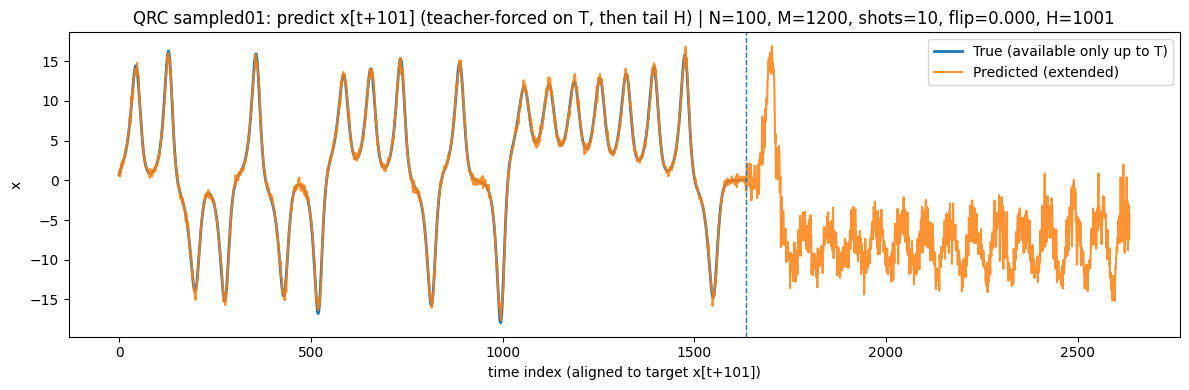

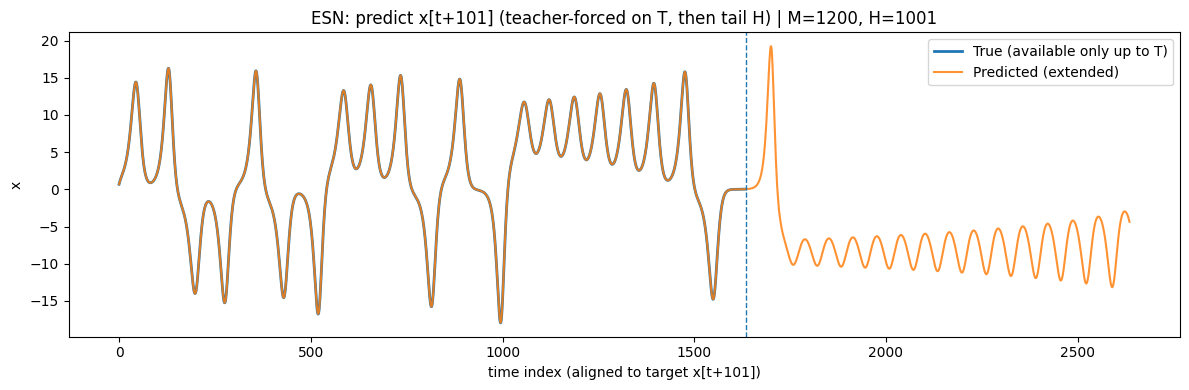

metrics_on_T: {'qrc': (0.18658734126839893, 0.9983258891557821), 'esn': (0.00012967628050893234, 0.9999988375155785)}
len(Y_train)      = 1635
len(Yhat_qrc_all) = 2636
len(Yhat_esn_all) = 2636


In [ ]:
res = compare_qrc_vs_esn_scalar_extend(
    lorenz_x_RK(6000),
    N=100,
    start_t=1000,
    T= len(lorenz_x_RK(3000)) - start_t - 1001,
    H=1001,     # 教師なしで101点延長
    seed=43,

    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    shots=10,      # 例：shots=10
    flip_p=0,  # 例：flip 7.5%

    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

# 返り値の中身（必要なら）
print("metrics_on_T:", res["metrics_on_T"])
print("len(Y_train)      =", len(res["Y_train"]))
print("len(Yhat_qrc_all) =", len(res["Yhat_qrc_all"]))
print("len(Yhat_esn_all) =", len(res["Yhat_esn_all"]))

[QRC sampled01] M=1200 shots=100 flip=0.000  (eval on first T only) MSE=0.102280  Corr=0.999083
[ESN tanh]     M=1200                        (eval on first T only) MSE=0.000130  Corr=0.999999
Tail forecast length (no teacher): H=1001


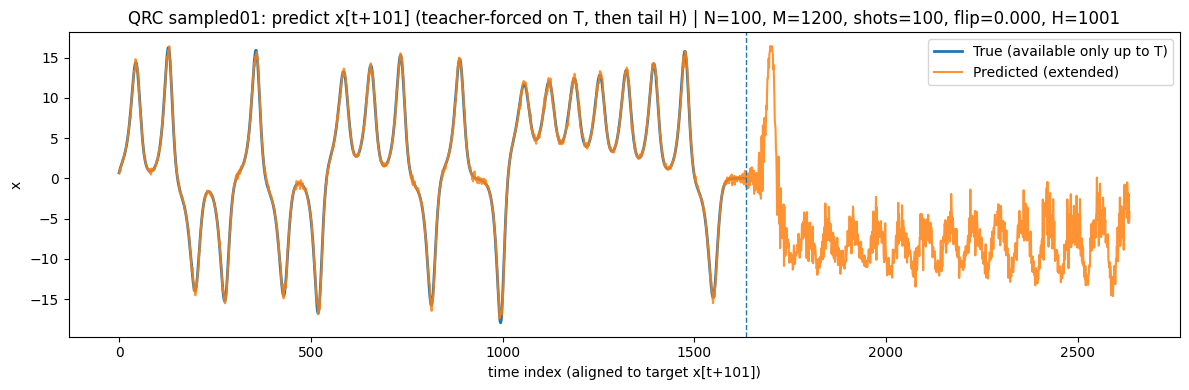

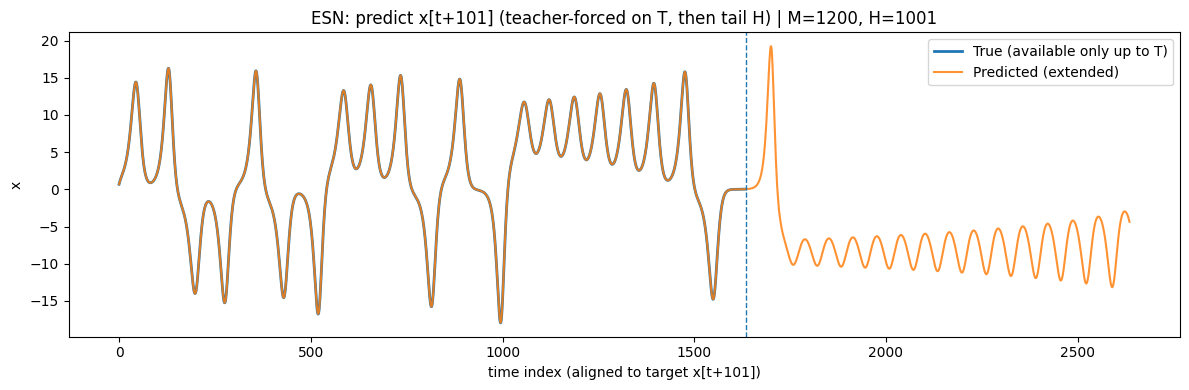

metrics_on_T: {'qrc': (0.10228021905611054, 0.9990826626932295), 'esn': (0.00012967628050893234, 0.9999988375155785)}
len(Y_train)      = 1635
len(Yhat_qrc_all) = 2636
len(Yhat_esn_all) = 2636


In [ ]:
res = compare_qrc_vs_esn_scalar_extend(
    lorenz_x_RK(6000),
    N=100,
    start_t=1000,
    T= len(lorenz_x_RK(3000)) - start_t - 1001,
    H=1001,     # 教師なしで101点延長
    seed=43,

    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    shots=100,      # 例：shots=10
    flip_p=0,  # 例：flip 7.5%

    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

# 返り値の中身（必要なら）
print("metrics_on_T:", res["metrics_on_T"])
print("len(Y_train)      =", len(res["Y_train"]))
print("len(Yhat_qrc_all) =", len(res["Yhat_qrc_all"]))
print("len(Yhat_esn_all) =", len(res["Yhat_esn_all"]))

[QRC sampled01] M=1200 shots=100 flip=0.075  (eval on first T only) MSE=0.160451  Corr=0.998561
[ESN tanh]     M=1200                        (eval on first T only) MSE=0.000130  Corr=0.999999
Tail forecast length (no teacher): H=1001


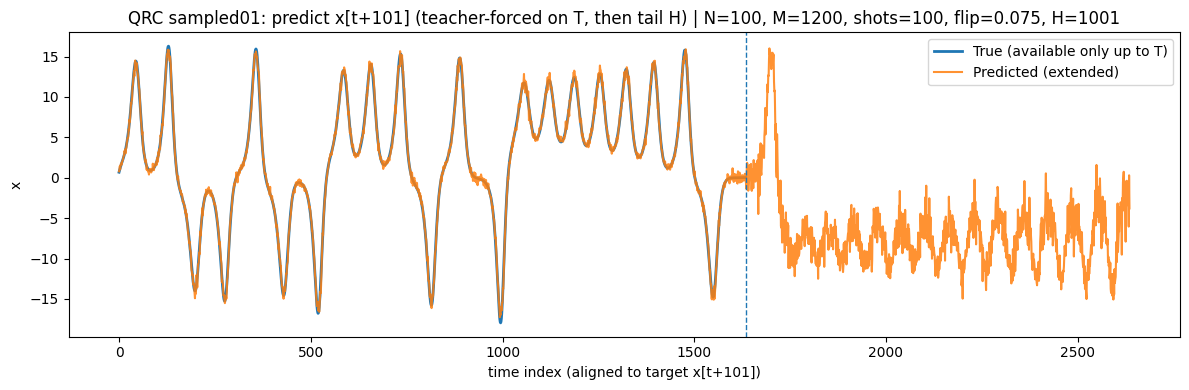

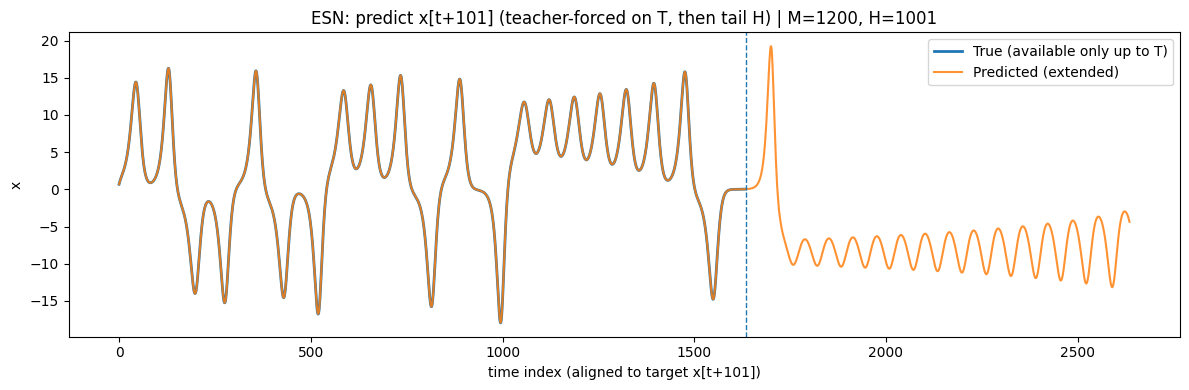

metrics_on_T: {'qrc': (0.16045109329491616, 0.9985605598866341), 'esn': (0.00012967628050893234, 0.9999988375155785)}
len(Y_train)      = 1635
len(Yhat_qrc_all) = 2636
len(Yhat_esn_all) = 2636


In [ ]:
res = compare_qrc_vs_esn_scalar_extend(
    lorenz_x_RK(6000),
    N=100,
    start_t=1000,
    T= len(lorenz_x_RK(3000)) - start_t - 1001,
    H=1001,     # 教師なしで101点延長
    seed=43,

    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    shots=100,      # 例：shots=10
    flip_p=0.075,  # 例：flip 7.5%

    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

# 返り値の中身（必要なら）
print("metrics_on_T:", res["metrics_on_T"])
print("len(Y_train)      =", len(res["Y_train"]))
print("len(Yhat_qrc_all) =", len(res["Yhat_qrc_all"]))
print("len(Yhat_esn_all) =", len(res["Yhat_esn_all"]))